In [1]:
#import atlite

import logging
logging.basicConfig(level=logging.INFO)

import geopandas as gpd

import matplotlib.pyplot as plt

#from atlite.gis import shape_availability, ExclusionContainer

import xarray as xr

import numpy as np
import pandas as pd

import requests

import io

import os

from shapely.geometry import Polygon
from shapely.geometry import Point

import cartopy.io.shapereader as shpreader
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.lines import Line2D

import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.crs import CRS
from rasterio.features import rasterize
from affine import Affine

import shapely
from shapely.geometry import Polygon
from shapely.geometry import mapping
from shapely.geometry import box
#from pyhighRES import constants

In [2]:
import mapclassify
import itertools
import fiona 

In [4]:
shapefile = shpreader.natural_earth(resolution='10m',
                                      category='cultural',
                                      name='admin_1_states_provinces')
world = gpd.read_file(shapefile)
Norway = world[world.iso_a2=="NO"]
Norway = Norway[["iso_3166_2","name","geometry"]]
Norway = Norway.set_index('iso_3166_2').drop(['NO-21', 'NO-X01~'])

In [5]:
Norway

,name,geometry
iso_3166_2,,
NO-19,Troms,"MULTIPOLYGON (((20.62316 69.03636, 20.36272 69..."
NO-18,Nordland,"MULTIPOLYGON (((18.18929 68.53842, 18.17184 68..."
NO-17,Nord-Trøndelag,"MULTIPOLYGON (((14.33207 65.11396, 14.31068 65..."
NO-16,Sør-Trøndelag,"MULTIPOLYGON (((12.05983 63.20477, 12.22270 63..."
NO-04,Hedmark,"POLYGON ((12.27952 62.34421, 12.28636 62.33542..."
NO-02,Akershus,"POLYGON ((11.87463 59.88494, 11.84959 59.87242..."
NO-01,Østfold,"MULTIPOLYGON (((11.88374 59.80538, 11.88980 59..."
NO-20,Finnmark,"MULTIPOLYGON (((28.95408 69.02726, 28.83961 69..."
NO-03,Oslo,"POLYGON ((10.75660 59.84416, 10.75847 59.85017..."


In [6]:
Trøndelag = gpd.GeoDataFrame([{'name':'Trøndelag', 'geometry':Norway.loc[['NO-17', 'NO-16']].unary_union}], index=['NO-50'])
TromsFinnmark = gpd.GeoDataFrame([{'name':'Troms og Finnmark', 'geometry':Norway.loc[['NO-19', 'NO-20']].unary_union}], index=['NO-54'])
Vestland = gpd.GeoDataFrame([{'name':'Vestland', 'geometry':Norway.loc[['NO-12', 'NO-14']].unary_union}], index=['NO-46'])
Viken = gpd.GeoDataFrame([{'name':'Viken', 'geometry':Norway.loc[['NO-02', 'NO-06', 'NO-01']].unary_union}], index=['NO-30'])
Innlandet = gpd.GeoDataFrame([{'name':'Innlandet', 'geometry':Norway.loc[['NO-04', 'NO-05']].unary_union}], index=['NO-34'])
VestfoldTelemark = gpd.GeoDataFrame([{'name':'Vestfold og Telemark', 'geometry':Norway.loc[['NO-07', 'NO-08']].unary_union}], index=['NO-38'])
Agder = gpd.GeoDataFrame([{'name':'Agder', 'geometry':Norway.loc[['NO-09', 'NO-10']].unary_union}], index=['NO-42'])
Nordland = gpd.GeoDataFrame([{'name':'Nordland', 'geometry':Norway.loc[['NO-18']].explode().drop(('NO-18',25)).unary_union}], index=['NO-18'])

Norway_11 = Norway.drop(['NO-17', 'NO-16', 'NO-19', 'NO-20', 'NO-12', 'NO-14', 'NO-02', 'NO-06',
                          'NO-01', 'NO-04', 'NO-05', 'NO-07', 'NO-08', 'NO-09', 'NO-10', 'NO-18'])

/tmp/ipykernel_3028133/2684897047.py:8: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  Nordland = gpd.GeoDataFrame([{'name':'Nordland', 'geometry':Norway.loc[['NO-18']].explode().drop(('NO-18',25)).unary_union}], index=['NO-18'])


In [7]:
Norway_11 = pd.concat([Norway_11, Trøndelag.set_crs(Norway_11.crs), TromsFinnmark.set_crs(Norway_11.crs),
                    Vestland.set_crs(Norway_11.crs), Viken.set_crs(Norway_11.crs), Innlandet.set_crs(Norway_11.crs),
                    VestfoldTelemark.set_crs(Norway_11.crs), Agder.set_crs(Norway_11.crs), Nordland.set_crs(Norway_11.crs)])

<AxesSubplot: >

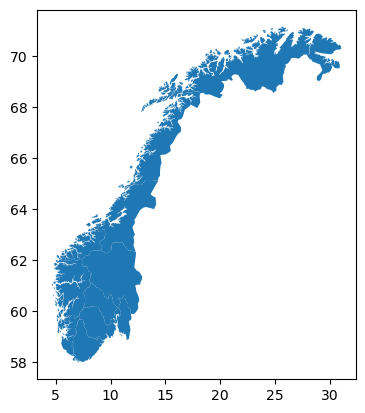

In [8]:
Norway_11 = Norway_11.sort_index()
Norway_11.plot()

In [9]:
Norway_11.index.name = 'fylke_code'

In [9]:
Norway_11.query("fylke_code == 'NO-03'")

,name,geometry
fylke_code,,
NO-03,Oslo,"POLYGON ((10.75660 59.84416, 10.75847 59.85017..."


In [22]:
NIBIO = pd.read_csv("/fp/homes01/u01/ec-javedm/ec85/models/shahzad/highRES-model/NIBIO_data.csv")

In [24]:
NIBIO['REGION'].unique()

array(['Sørlandet', 'Vestlandet', 'Østlandet', 'Trøndelag', 'Nord-Norge'],
      dtype=object)

In [25]:
NIBIO

,FLATEID,SESONG,LOREYS_HEIGHT,UTM_S33_OV_CA,UTM_S33_SN_CA,ABONITET,BEST_ALDER,SKOGKARAKTER,FAWS,FYLKESNAVN,REGION
0,A03059,2019,17.94,16000.0,6466000.0,11.0,65.0,1,0,Agder,Sørlandet
1,A03099,2023,4.40,9000.0,6476000.0,NaN,55.0,1,0,Agder,Sørlandet
2,A03102,2020,6.80,14000.0,6469000.0,11.0,NaN,1,1,Agder,Sørlandet
3,A03105,2020,8.51,14000.0,6472000.0,NaN,27.0,1,0,Agder,Sørlandet
4,A03107,2020,6.83,12000.0,6475000.0,NaN,65.0,1,0,Agder,Sørlandet
...,...,...,...,...,...,...,...,...,...,...,...
10505,A08172,2020,0.00,40000.0,6529000.0,NaN,85.0,1,0,Agder,Sørlandet
10506,A44071,2022,0.00,90000.0,6914000.0,NaN,55.0,1,0,Møre og Romsdal,Vestlandet
10507,A35012,2022,0.00,25000.0,6822000.0,NaN,53.0,1,0,Vestland,Vestlandet
10508,D72042,2020,0.00,498000.0,7401000.0,NaN,90.0,1,0,Nordland,Nord-Norge


In [29]:
NIBIO['geometry'] = NIBIO.apply(lambda row: Point(row['UTM_S33_OV_CA'], row['UTM_S33_SN_CA']), axis=1)

In [31]:
NIBIO_gdf = gpd.GeoDataFrame(NIBIO, geometry='geometry', crs="EPSG:32633")

In [33]:
NIBIO_gdf = NIBIO_gdf.to_crs(epsg=4326)

In [34]:
NIBIO_gdf

,FLATEID,SESONG,LOREYS_HEIGHT,UTM_S33_OV_CA,UTM_S33_SN_CA,ABONITET,BEST_ALDER,SKOGKARAKTER,FAWS,FYLKESNAVN,REGION,geometry
0,A03059,2019,17.94,16000.0,6466000.0,11.0,65.0,1,0,Agder,Sørlandet,POINT (6.78335 58.06968)
1,A03099,2023,4.40,9000.0,6476000.0,NaN,55.0,1,0,Agder,Sørlandet,POINT (6.64504 58.15086)
2,A03102,2020,6.80,14000.0,6469000.0,11.0,NaN,1,1,Agder,Sørlandet,POINT (6.74360 58.09416)
3,A03105,2020,8.51,14000.0,6472000.0,NaN,27.0,1,0,Agder,Sørlandet,POINT (6.73739 58.12082)
4,A03107,2020,6.83,12000.0,6475000.0,NaN,65.0,1,0,Agder,Sørlandet,POINT (6.69755 58.14529)
...,...,...,...,...,...,...,...,...,...,...,...,...
10505,A08172,2020,0.00,40000.0,6529000.0,NaN,85.0,1,0,Agder,Sørlandet,POINT (7.06065 58.65568)
10506,A44071,2022,0.00,90000.0,6914000.0,NaN,55.0,1,0,Møre og Romsdal,Vestlandet,POINT (7.12379 62.13331)
10507,A35012,2022,0.00,25000.0,6822000.0,NaN,53.0,1,0,Vestland,Vestlandet,POINT (6.13132 61.24142)
10508,D72042,2020,0.00,498000.0,7401000.0,NaN,90.0,1,0,Nordland,Nord-Norge,POINT (14.95464 66.72747)


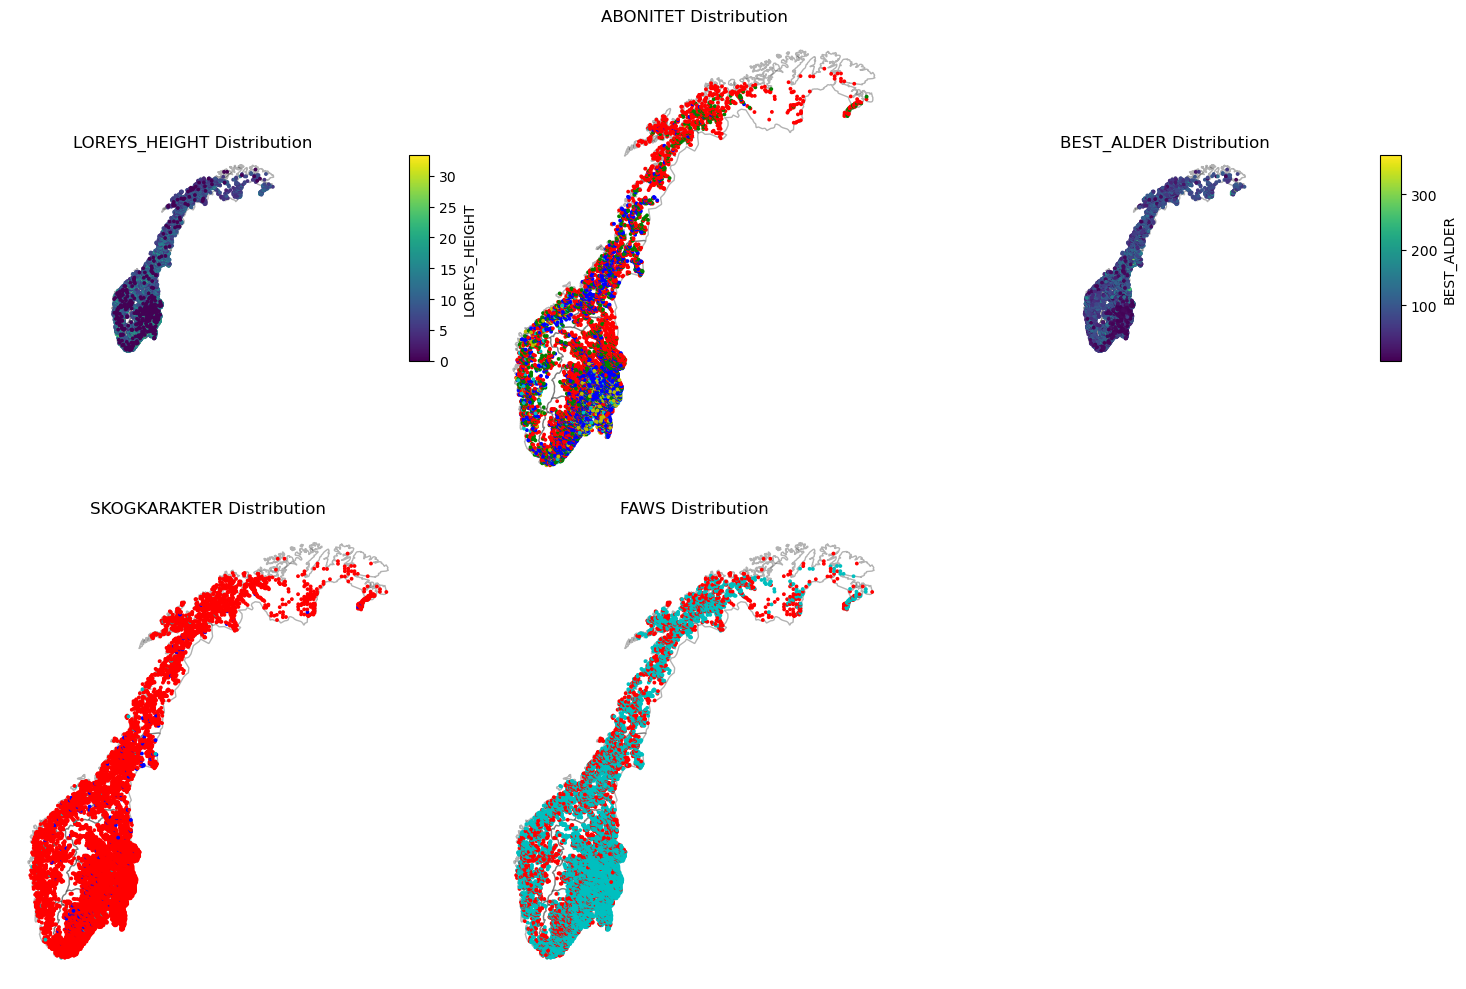

In [48]:
# Plot settings
categories = ['LOREYS_HEIGHT', 'ABONITET', 'BEST_ALDER', 'SKOGKARAKTER', 'FAWS']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

ax = axes[idx]
Norway_11.plot(ax=ax, facecolor="none", edgecolor="black", alpha=0.3)
dropna = NIBIO_gdf.dropna(subset=['ABONITET'])
cmap = ListedColormap(['r', 'g', 'b', 'y', 'c'])
dropna.plot(ax=ax,
            column=category,
            cmap=cmap, 
            markersize=3)
ax.set_title(f'{category} Distribution', fontsize=12)
ax.set_axis_off()


for idx, category in enumerate(categories):
    ax = axes[idx]
    Norway_11.plot(ax=ax, facecolor="none", edgecolor="black", alpha=0.3)
    dropna = NIBIO_gdf.dropna(subset=[category])
    if category in ['LOREYS_HEIGHT', 'BEST_ALDER']:  # Continuous
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        
        
        dropna.plot(ax=ax,
                 column=category, 
                 cmap='viridis',
                 markersize=3,
                 legend=True,
                 cax=cax,
                 legend_kwds={'label': category, 'orientation': "vertical"})
    else:  # Discrete values
        cmap = ListedColormap(['r', 'g', 'b', 'y', 'c'])
        dropna.plot(ax=ax,
                 column=category,
                 cmap=cmap, 
                 markersize=3)

    # Highlight NaN values with different markers
    #nan_gdf = NIBIO_gdf[NIBIO_gdf[category].isnull()]
    #nan_gdf.plot(ax=ax, color='grey', markersize=50, marker='x', label="Missing Data")

    # Custom plot settings
    ax.set_title(f'{category} Distribution', fontsize=12)
    ax.set_axis_off()

# Hide any unused subplots
for ax in axes[len(categories):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [112]:
print(NIBIO_gdf['FAWS'].value_counts(normalize=True).sort_index())

0    0.266698
1    0.733302
Name: FAWS, dtype: float64


In [69]:
NIBIO_gdf[NIBIO_gdf['ABONITET'].isnull()]

,FLATEID,SESONG,LOREYS_HEIGHT,UTM_S33_OV_CA,UTM_S33_SN_CA,ABONITET,BEST_ALDER,SKOGKARAKTER,FAWS,FYLKESNAVN,REGION,geometry
1,A03099,2023,4.40,9000.0,6476000.0,NaN,55.0,1,0,Agder,Sørlandet,POINT (6.64504 58.15086)
3,A03105,2020,8.51,14000.0,6472000.0,NaN,27.0,1,0,Agder,Sørlandet,POINT (6.73739 58.12082)
4,A03107,2020,6.83,12000.0,6475000.0,NaN,65.0,1,0,Agder,Sørlandet,POINT (6.69755 58.14529)
6,A03143,2022,9.16,9000.0,6479000.0,NaN,62.0,1,0,Agder,Sørlandet,POINT (6.63874 58.17752)
9,A03156,2023,18.81,18000.0,6480000.0,NaN,55.0,1,0,Agder,Sørlandet,POINT (6.78812 58.19631)
...,...,...,...,...,...,...,...,...,...,...,...,...
10505,A08172,2020,0.00,40000.0,6529000.0,NaN,85.0,1,0,Agder,Sørlandet,POINT (7.06065 58.65568)
10506,A44071,2022,0.00,90000.0,6914000.0,NaN,55.0,1,0,Møre og Romsdal,Vestlandet,POINT (7.12379 62.13331)
10507,A35012,2022,0.00,25000.0,6822000.0,NaN,53.0,1,0,Vestland,Vestlandet,POINT (6.13132 61.24142)
10508,D72042,2020,0.00,498000.0,7401000.0,NaN,90.0,1,0,Nordland,Nord-Norge,POINT (14.95464 66.72747)


/tmp/ipykernel_310014/3437490900.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


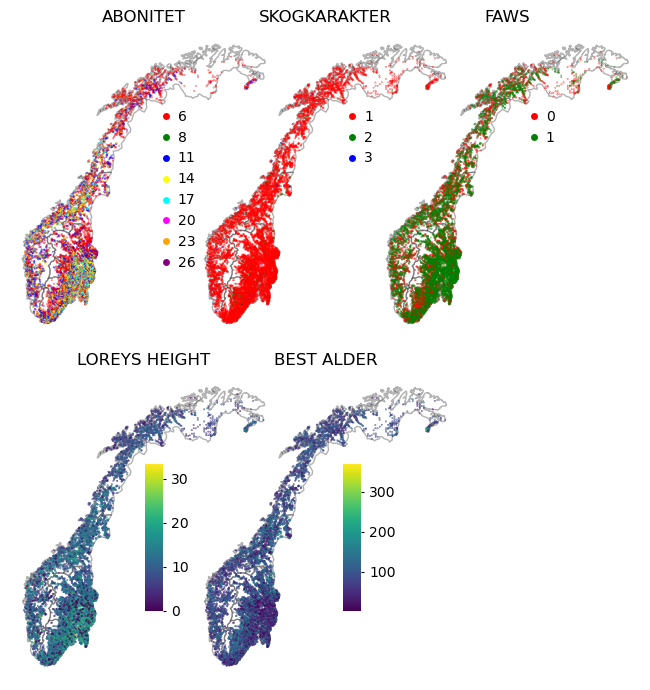

In [111]:
categories = ['LOREYS_HEIGHT', 'ABONITET', 'BEST_ALDER', 'SKOGKARAKTER', 'FAWS']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(9, 7))
fig.subplots_adjust(wspace=-1.2, left=0.15, right=0.75, top=1, bottom=0.2)
axes = axes.flatten()

abonitet_cmap = ListedColormap(['red', 'green', 'blue', 'yellow', 'cyan', 'magenta', 'orange', 'purple', 'grey'])
skogkarakter_cmap = ListedColormap(['red', 'green', 'blue'])
faws_cmap = ListedColormap(['red', 'green'])


ax = axes[0]
Norway_11.plot(ax=ax, facecolor="none", edgecolor="black", alpha=0.3)
gdf_abonitet = NIBIO_gdf.dropna(subset=['ABONITET'])
#nan_gdf_abonitet = NIBIO_gdf[NIBIO_gdf['ABONITET'].isnull()]
#nan_gdf_abonitet.plot(ax=ax, color='grey', marker='x', markersize=0.1, label='Missing Data')
gdf_abonitet.plot(ax=ax,
            column='ABONITET',
            cmap=abonitet_cmap, 
            markersize=0.05)

legend_labels = ['6', '8', '11', '14', '17', '20', '23', '26']
colors = ['red', 'green', 'blue', 'yellow', 'cyan', 'magenta', 'orange', 'purple', 'grey']
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=6, label=label)
                   for color, label in zip(colors, legend_labels)]

ax.legend(handles=legend_elements, title="", loc='upper center', bbox_to_anchor=(0.63, 0.76), borderaxespad=0, frameon=False, 
          fontsize=10, handlelength=0.7, handletextpad=0.5)

ax.set_title( 'ABONITET', fontsize=12)
ax.set_axis_off()


ax = axes[1]
Norway_11.plot(ax=ax, facecolor="none", edgecolor="black", alpha=0.3)
#dropna = NIBIO_gdf.dropna(subset=['SKOGKARAKTER'])
NIBIO_gdf.plot(ax=ax,
            column='SKOGKARAKTER',
            cmap=skogkarakter_cmap, 
            markersize=0.05)

legend_labels = ['1', '2', '3']
colors = ['red', 'green', 'blue']
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=6, label=label)
                   for color, label in zip(colors, legend_labels)]
ax.legend(handles=legend_elements, title="", loc='upper center', bbox_to_anchor=(0.63, 0.76), borderaxespad=0, frameon=False, 
          fontsize=10, handlelength=0.7, handletextpad=0.5)

ax.set_title( 'SKOGKARAKTER', fontsize=12)
ax.set_axis_off()


ax = axes[2]
Norway_11.plot(ax=ax, facecolor="none", edgecolor="black", alpha=0.3)
#dropna = NIBIO_gdf.dropna(subset=['SKOGKARAKTER'])
NIBIO_gdf.plot(ax=ax,
            column='FAWS',
            cmap=faws_cmap, 
            markersize=0.05)


legend_labels = ['0', '1']
colors = ['red', 'green']
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=6, label=label)
                   for color, label in zip(colors, legend_labels)]
ax.legend(handles=legend_elements, title="", loc='upper center', bbox_to_anchor=(0.63, 0.76), borderaxespad=0, frameon=False, 
          fontsize=10, handlelength=0.7, handletextpad=0.5)


ax.set_title( 'FAWS', fontsize=12)
ax.set_axis_off()

ax = axes[3]
Norway_11.plot(ax=ax, facecolor="none", edgecolor="black", alpha=0.3)
#dropna = NIBIO_gdf.dropna(subset=['SKOGKARAKTER'])
#divider = make_axes_locatable(ax)
#cax = divider.append_axes("right", size="3%", pad=-1)
NIBIO_gdf.plot(ax=ax,
            column='LOREYS_HEIGHT', 
            cmap='viridis',
            markersize=0.1,
            legend=False,
              )

ax_color_scale = fig.add_axes([0.3, 0.12, 0.02, 0.21])
norm = plt.Normalize(vmin=NIBIO_gdf['LOREYS_HEIGHT'].min(), 
                         vmax=NIBIO_gdf['LOREYS_HEIGHT'].max())
cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'), 
                      cax=ax_color_scale, orientation='vertical')
cb.set_label('', fontsize=10)
#new_ticks = [0, 100, 200, 300]
#cb.set_ticks(new_ticks)
cb.outline.set_visible(False)
cb.ax.tick_params(length=2)

ax.set_title( 'LOREYS HEIGHT', fontsize=12)
ax.set_axis_off()


ax = axes[4]
Norway_11.plot(ax=ax, facecolor="none", edgecolor="black", alpha=0.3)
gdf_best_alder = NIBIO_gdf.dropna(subset=['BEST_ALDER'])
gdf_best_alder.plot(ax=ax,
            column='BEST_ALDER', 
            cmap='viridis',
            markersize=0.1,
            legend=False,
                   )

ax_color_scale = fig.add_axes([0.52, 0.12, 0.02, 0.21])
norm = plt.Normalize(vmin=NIBIO_gdf['BEST_ALDER'].min(), 
                         vmax=NIBIO_gdf['BEST_ALDER'].max())
cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'), 
                      cax=ax_color_scale, orientation='vertical')
cb.set_label('', fontsize=10)
cb.outline.set_visible(False)
cb.ax.tick_params(length=2)
ax.set_title( 'BEST ALDER', fontsize=12)
ax.set_axis_off()


axes[-1].set_visible(False)
plt.tight_layout()

plt.savefig('/fp/homes01/u01/ec-javedm/ec85/models/shahzad/Forests_plot.png', dpi=300, bbox_inches='tight')
#plt.savefig('/fp/homes01/u01/ec-javedm/ec85/models/shahzad/Plots/updated/transperent/store_ecap_zonal2.png', dpi=300, transparent=True, bbox_inches='tight')


plt.show()

In [3]:
# Function for obtaining bounding box in the new CRS

def get_bounding():
    rectx1 = 4.5936268
    rectx2 = 33.2415665
    recty1 = 57.408891
    recty2 = 71.339783
    
    polygon = Polygon(
        [
            (rectx1, recty1),
            (rectx1, recty2),
            (rectx2, recty2),
            (rectx2, recty1),
            (rectx1, recty1),
        ]
    )
    
    # Segmentize or refine polygon
    polygon = shapely.segmentize(polygon, max_segment_length=0.5)
    geo_df = gpd.GeoDataFrame(geometry=[polygon], crs="EPSG:4326")
    # Re-project to new CRS
    return geo_df.to_crs("EPSG:3035")

In [192]:
def process_rasterize_SRRBONITET(tiff_in, categories_to_include, out_shape):
    
    with rasterio.open(tiff_in) as src:
    # Read the data
        data = src.read(1)  # Reads the first band of the image
        minx, miny, maxx, maxy = get_bounding().total_bounds
        
        # Calculate new transform
        new_transform = Affine.translation(minx, maxy) * Affine.scale(
            (maxx - minx) / src.width,
            (miny - maxy) / src.height
        )
        # Calculate new width and height
        new_width = int((maxx - minx) / new_transform.a)
        new_height = int((maxy - miny) / -new_transform.e)
    
        # Retrieve metadata if needed
        kwargs = src.meta.copy()
    
        kwargs.update({
        'crs': CRS.from_epsg(3035),
        'transform': new_transform,
        'width': new_width,
        'height': new_height,
        'dtype': 'uint8',
        'nodata': 0,  # Setting nodata to zero for binary   
        #'compress': 'lzw',  # Add LZW compression
        'compress': 'deflate'  # Add LZW compression    
        })
    
        # Create an empty array for the destination data
        #dst_array = np.zeros((new_height, new_width), dtype=np.uint8)
        dst_array = np.full((new_height, new_width), -9999, dtype=np.int32)
        
        reproject(
            source=rasterio.band(src, 1),  # Use processed binary exclusion data
            destination=dst_array,  # Initialize destination array
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=new_transform,
            dst_crs=CRS.from_epsg(3035),
            resampling=Resampling.nearest
        )
    
        # Convert reprojected data to binary mask
        binary_data = np.isin(dst_array, categories_to_include).astype(np.uint8)
    
        with rasterio.open(out_shape, 'w', **kwargs) as dst:  
             dst.write(binary_data, 1)    
            


## Bonitet (SRBONITET)

In [175]:

def process_rasterize_SRRBONITET_one(tiff_in, band_index, categories_to_include, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read(band_index)  # Reads the first band of the image
    
        # Retrieve metadata if needed
        kwargs = src.meta.copy()
        
        kwargs.update({
            'count': 1,
            'dtype': 'uint8',
            'nodata': 255,  # Set nodata to zero for binary representation
            'compress': 'deflate'  # Add compression
        })

        processed_data = np.where(data == -9999, 255,
                          np.where(np.isin(data, categories_to_include), 1, 0)).astype(np.uint8)

        with rasterio.open(out_shape, 'w', **kwargs) as dst:          
            dst.write(processed_data, 1)    



In [176]:
#Biomass data: range is [0 to 826] in tonn/ha. -9999 represents nodata
#TODO: description of band_index...
def process_rasterize_SRRBONITET_two(tiff_in, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read()  # Reads the first band of the image
        minx, miny, maxx, maxy = get_bounding().total_bounds

        # Calculate new transform
        new_transform = Affine.translation(minx, maxy) * Affine.scale(
            (maxx - minx) / src.width,
            (miny - maxy) / src.height
        )
        
        # Calculate new width and height
        new_width = int((maxx - minx) / new_transform.a)
        new_height = int((maxy - miny) / -new_transform.e)

        # Retrieve metadata if needed
        kwargs = src.meta.copy()

        kwargs.update({
            'crs': CRS.from_epsg(3035),
            'transform': new_transform,
            'width': new_width,
            'height': new_height,
            'compress': 'deflate'  # Add compression
        })


        with rasterio.open(out_shape, 'w', **kwargs) as dst:  
            # Reproject the data
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=CRS.from_epsg(3035),
                resampling=Resampling.nearest
            )    


In [281]:
#total categories: [-9999,     0,     6,     8,    11,    14,    17,    20,    23] with -9999 nodata
categories_to_include_low = [0, 6, 8, 11]
tiff_in_BONITET = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRBONITET.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBONITET_PLi.tif'
process_rasterize_SRRBONITET_one(tiff_in_BONITET, 1, categories_to_include_low, out_shape)

In [282]:
tiff_in_BONITET = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBONITET_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRBONITET_PLF.tif'
process_rasterize_SRRBONITET_two(tiff_in_BONITET, out_shape)

In [81]:
categories_to_include_high = [0, 6, 8]
tiff_in_BONITET = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRBONITET.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBONITET_PHi.tif'
process_rasterize_SRRBONITET_one(tiff_in_BONITET, 1, categories_to_include_high, out_shape)

In [82]:
tiff_in_BONITET = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBONITET_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRBONITET_PHF.tif'
process_rasterize_SRRBONITET_two(tiff_in_BONITET, out_shape)

### Jenks breaks

In [ ]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRBONITET.tif') as src_Bonitet:
    # Read the data
        data_Bonitet = src_Bonitet.read(1)  # Reads the first band of the image
flattened_data = data_Bonitet.flatten()
nodata_value = -9999
cleaned_data = flattened_data[(flattened_data != nodata_value) & (~np.isnan(flattened_data))]
num_classes = 3  # Define the number of desired classes
jenks_breaks_bonitet = mapclassify.JenksCaspall(cleaned_data, k=num_classes)

In [109]:
jenks_breaks_bonitet

JenksCaspall

   Interval          Count
--------------------------
[ 0.00,  0.00] | 106668955
( 0.00, 11.00] | 236066384
(11.00, 23.00] | 109294636

In [177]:
#categories_to_include_low = [0, 6, 8, 11]
categories_to_include_low = [14, 20, 23]
tiff_in_BONITET = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/SRRBONITET.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRBONITET_PLi.tif'
process_rasterize_SRRBONITET_one(tiff_in_BONITET, 1, categories_to_include_low, out_shape)

In [178]:
tiff_in_BONITET = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRBONITET_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/SRRBONITET_PLE.tif'
process_rasterize_SRRBONITET_two(tiff_in_BONITET, out_shape)

In [180]:
#categories_to_include_high = [0]
categories_to_include_high = [6, 8, 11, 14, 20, 23]
tiff_in_BONITET = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/SRRBONITET.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRBONITET_PHi.tif'
process_rasterize_SRRBONITET_one(tiff_in_BONITET, 1, categories_to_include_high, out_shape)

In [181]:
tiff_in_BONITET = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRBONITET_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/SRRBONITET_PHE.tif'
process_rasterize_SRRBONITET_two(tiff_in_BONITET, out_shape)

In [115]:
#total categories: [-9999,     0,     6,     8,    11,    14,    17,    20,    23] with -9999 nodata
categories_to_include_low = [0, 6, 8, 11, 14, 20, 23]
tiff_in_BONITET = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/SRRBONITET.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Scenarios/SRRBONITET_alli.tif'
process_rasterize_SRRBONITET_one(tiff_in_BONITET, 1, categories_to_include_low, out_shape)

In [116]:
tiff_in_BONITET = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Scenarios/SRRBONITET_alli.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Scenarios/SRRBONITET_all.tif'
process_rasterize_SRRBONITET_two(tiff_in_BONITET, out_shape)

## Biomasse overjordisk (SRBMO)

In [32]:
#Biomass data: range is [0 to 826] in tonn/ha. -9999 represents nodata
#TODO: description of band_index...
def process_rasterize_biomass_one(tiff_in, band_index, threshold1, threshold2, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read(band_index)  # Reads the first band of the image
        
        # Retrieve metadata if needed
        kwargs = src.meta.copy()
        
        kwargs.update({
            'count': 1,
            'dtype': 'int8',
            'nodata': -127,  # Set nodata to zero for binary representation
            'compress': 'deflate'  # Add compression
        })

        #processed_data = np.where(data == -9999, -127,
        #                         np.where((data >= 0) & (data < threshold1), 1, 0)).astype(np.int8)
        #processed_data = np.where(data == -9999, -127,
        #                         np.where((data > threshold1), 1, 0)).astype(np.int8)        
        processed_data = np.where(data == -9999, -127,
                          np.where((data >= 0) & ((data < threshold1) | (data > threshold2)), 0, 1)).astype(np.int8)
        with rasterio.open(out_shape, 'w', **kwargs) as dst:          
            dst.write(processed_data, 1)    


In [33]:
#Biomass data: range is [0 to 826] in tonn/ha. -9999 represents nodata
#TODO: description of band_index...
def process_rasterize_biomass_two(tiff_in, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read()  # Reads the first band of the image
        minx, miny, maxx, maxy = get_bounding().total_bounds

        # Calculate new transform
        new_transform = Affine.translation(minx, maxy) * Affine.scale(
            (maxx - minx) / src.width,
            (miny - maxy) / src.height
        )
        
        # Calculate new width and height
        new_width = int((maxx - minx) / new_transform.a)
        new_height = int((maxy - miny) / -new_transform.e)

        # Retrieve metadata if needed
        kwargs = src.meta.copy()

        kwargs.update({
            'crs': CRS.from_epsg(3035),
            'transform': new_transform,
            'width': new_width,
            'height': new_height,
            'compress': 'deflate'  # Add compression
        })


        with rasterio.open(out_shape, 'w', **kwargs) as dst:  
            # Reproject the data
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=CRS.from_epsg(3035),
                resampling=Resampling.nearest
            )    


In [13]:
tiff_in_BMO = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRBMO.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBMO_PLi.tif'
process_rasterize_biomass_one(tiff_in_BMO, 1,  99, out_shape)

In [14]:
tiff_in_BMO = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBMO_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRBMO_PLF.tif'
process_rasterize_biomass_two(tiff_in_BMO, out_shape)

In [15]:
tiff_in_BMO = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRBMO.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBMO_PMi.tif'
process_rasterize_biomass_one(tiff_in_BMO, 1,  48, out_shape)

In [16]:
tiff_in_BMO = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBMO_PMi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRBMO_PMF.tif'
process_rasterize_biomass_two(tiff_in_BMO, out_shape)

In [17]:
tiff_in_BMO = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRBMO.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBMO_PHi.tif'
process_rasterize_biomass_one(tiff_in_BMO, 1,  19, out_shape)

In [18]:
tiff_in_BMO = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBMO_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRBMO_PHF.tif'
process_rasterize_biomass_two(tiff_in_BMO, out_shape)

### Jenks breaks

In [ ]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRBMO.tif') as src_BMO:
    # Read the data
        data_BMO1 = src_BMO.read(1)  # Reads the first band of the image
        data_BMO2 = src_BMO.read(2)
        data_BMO3 = src_BMO.read(3)
flattened_data = data_BMO1.flatten()
nodata_value = -9999
cleaned_data = flattened_data[(flattened_data != nodata_value) & (~np.isnan(flattened_data))]
num_classes = 3  # Define the number of desired classes
jenks_breaks_BMO = mapclassify.JenksCaspall(cleaned_data, k=num_classes)

In [197]:
jenks_breaks_3

JenksCaspall

    Interval           Count
----------------------------
[  0.00,  47.00] | 223174744
( 47.00, 121.00] | 146203783
(121.00, 826.00] |  81856760

In [191]:
tiff_in_BMO = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/SRRBMO.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRBMO_PLi.tif'
process_rasterize_biomass_one(tiff_in_BMO, 1,  121, out_shape)

In [192]:
tiff_in_BMO = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRBMO_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/SRRBMO_PLE.tif'
process_rasterize_biomass_two(tiff_in_BMO, out_shape)

In [193]:
tiff_in_BMO = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/SRRBMO.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRBMO_PHi.tif'
process_rasterize_biomass_one(tiff_in_BMO, 1,  47, out_shape)

In [194]:
tiff_in_BMO = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRBMO_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/SRRBMO_PHE.tif'
process_rasterize_biomass_two(tiff_in_BMO, out_shape)

In [34]:
tiff_in_BMO = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/SRRBMO.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/SRRBMO_LLPi.tif'
process_rasterize_biomass_one(tiff_in_BMO, 1,  47, 121, out_shape)

In [35]:
tiff_in_BMO = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/SRRBMO_LLPi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Scenarios/SRRBMO_LLPE.tif'
process_rasterize_biomass_two(tiff_in_BMO, out_shape)

## Treantall

In [126]:
#Treantall data with diameter greater then 5 cm: range is [0 to 5384] in tree/ha. -9999 represents nodata
#TODO: description of band_index...
def process_rasterize_treantall_one(tiff_in, band_index, threshold, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read(band_index)  # Reads the first band of the image

        # Retrieve metadata if needed
        kwargs = src.meta.copy()
        
        kwargs.update({
            'count': 1,
            'dtype': 'int8',
            'nodata': -127,  # Set nodata to zero for binary representation
            'compress': 'deflate'  # Add compression
        })

        #binary_data = np.where((data >= 0) & (data < threshold), 1, 0).astype(np.uint8)
        processed_data = np.where(data == -9999, -127,
                                  np.where((data >= 0) & (data < threshold), 1, 0)).astype(np.int8)
        with rasterio.open(out_shape, 'w', **kwargs) as dst:          
            dst.write(processed_data, 1)    


In [127]:

#TODO: description of band_index...
def process_rasterize_treantall_two(tiff_in, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read()  # Reads the first band of the image
        minx, miny, maxx, maxy = get_bounding().total_bounds

        # Calculate new transform
        new_transform = Affine.translation(minx, maxy) * Affine.scale(
            (maxx - minx) / src.width,
            (miny - maxy) / src.height
        )
        
        # Calculate new width and height
        new_width = int((maxx - minx) / new_transform.a)
        new_height = int((maxy - miny) / -new_transform.e)

        # Retrieve metadata if needed
        kwargs = src.meta.copy()

        kwargs.update({
            'crs': CRS.from_epsg(3035),
            'transform': new_transform,
            'width': new_width,
            'height': new_height,
            'compress': 'deflate'  # Add compression
        })


        with rasterio.open(out_shape, 'w', **kwargs) as dst:  
            # Reproject the data
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=CRS.from_epsg(3035),
                resampling=Resampling.nearest
            )    


In [21]:
tiff_in_treantall = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREANTALL.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREANTALL_PLi.tif'
process_rasterize_treantall_one(tiff_in_treantall, 1,  1225, out_shape)


In [22]:
tiff_in_treantall = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREANTALL_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRTREANTALL_PLF.tif'
process_rasterize_treantall_two(tiff_in_treantall, out_shape)

In [ ]:
tiff_in_treantall = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREANTALL.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREANTALL_PMi.tif'
process_rasterize_treantall_one(tiff_in_treantall, 1,  783, out_shape)


In [24]:
tiff_in_treantall = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREANTALL_PMi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRTREANTALL_PMF.tif'
process_rasterize_treantall_two(tiff_in_treantall, out_shape)

In [25]:
tiff_in_treantall = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREANTALL.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREANTALL_PHi.tif'
process_rasterize_treantall_one(tiff_in_treantall, 1,  476, out_shape)

In [26]:
tiff_in_treantall = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREANTALL_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRTREANTALL_PHF.tif'
process_rasterize_treantall_two(tiff_in_treantall, out_shape)

### Jenks breaks

In [125]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREANTALL.tif') as src_treantall:
    # Read the data
        data_treantall = src_treantall.read(1)  # Reads the first band of the image

flattened_data = data_treantall.flatten()
nodata_value = -9999
cleaned_data = flattened_data[(flattened_data != nodata_value) & (~np.isnan(flattened_data))]
num_classes = 3  # Define the number of desired classes
jenks_breaks_treantall = mapclassify.JenksCaspall(cleaned_data, k=num_classes)

In [128]:
jenks_breaks_treantall

JenksCaspall

     Interval            Count
------------------------------
[   0.00,  669.00] | 187187139
( 669.00, 1240.00] | 154410183
(1240.00, 5384.00] | 109640524

In [129]:
tiff_in_treantall = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREANTALL.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRTREANTALL_PLi.tif'
process_rasterize_treantall_one(tiff_in_treantall, 1,  jenks_breaks_treantall.bins[1], out_shape)


In [130]:
tiff_in_treantall = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRTREANTALL_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/SRRTREANTALL_PLF.tif'
process_rasterize_treantall_two(tiff_in_treantall, out_shape)

In [131]:
tiff_in_treantall = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREANTALL.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRTREANTALL_PHi.tif'
process_rasterize_treantall_one(tiff_in_treantall, 1,  jenks_breaks_treantall.bins[0], out_shape)

In [132]:
tiff_in_treantall = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRTREANTALL_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/SRRTREANTALL_PHF.tif'
process_rasterize_treantall_two(tiff_in_treantall, out_shape)

## Tree age (TREALDER)

In [28]:
#Trealder data with for tree ages range is [0 to 365] in years. -9999 represents nodata
#TODO: description of band_index...
def process_rasterize_trealder_one(tiff_in, band_index, threshold1, threshold2, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read(band_index)  # Reads the first band of the image

        # Retrieve metadata if needed
        kwargs = src.meta.copy()
        
        kwargs.update({
            'count': 1,
            'dtype': 'int8',
            'nodata': -127,  # Set nodata to zero for binary representation
            'compress': 'deflate'  # Add compression
        })

        #processed_data = np.where(data == -9999, -127,
        #                         np.where((data >= 0) & (data < threshold1) , 1, 0)).astype(np.int8)
        #processed_data = np.where(data == -9999, -127,
        #                 np.where((data > threshold1) , 1, 0)).astype(np.int8)
        processed_data = np.where(data == -9999, -127,
                  np.where((data >= 0) & ((data < threshold1) | (data > threshold2)), 0, 1)).astype(np.int8)
        with rasterio.open(out_shape, 'w', **kwargs) as dst:          
            dst.write(processed_data, 1)    


In [29]:

#TODO: description of band_index...
def process_rasterize_trealder_two(tiff_in, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read()  # Reads the first band of the image
        minx, miny, maxx, maxy = get_bounding().total_bounds

        # Calculate new transform
        new_transform = Affine.translation(minx, maxy) * Affine.scale(
            (maxx - minx) / src.width,
            (miny - maxy) / src.height
        )
        
        # Calculate new width and height
        new_width = int((maxx - minx) / new_transform.a)
        new_height = int((maxy - miny) / -new_transform.e)

        # Retrieve metadata if needed
        kwargs = src.meta.copy()

        kwargs.update({
            'crs': CRS.from_epsg(3035),
            'transform': new_transform,
            'width': new_width,
            'height': new_height,
            'compress': 'deflate'  # Add compression
        })


        with rasterio.open(out_shape, 'w', **kwargs) as dst:  
            # Reproject the data
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=CRS.from_epsg(3035),
                resampling=Resampling.nearest
            )    


In [29]:
tiff_in_trealder = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREALDER.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREALDER_PLi.tif'
process_rasterize_trealder_one(tiff_in_trealder, 1,  83, out_shape)


In [30]:
tiff_in_trealder = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREALDER_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRTREALDER_PLF.tif'
process_rasterize_trealder_two(tiff_in_trealder, out_shape)

In [13]:
#very restrictive scenario
tiff_in_trealder = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/SRRTREALDER.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/SRRTREALDER_PMi.tif'
process_rasterize_trealder_one(tiff_in_trealder, 1,  85, out_shape)


In [14]:
tiff_in_trealder = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/SRRTREALDER_PMi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Scenarios/VRS/SRRTREALDER_VRS.tif'
process_rasterize_trealder_two(tiff_in_trealder, out_shape)

In [31]:
tiff_in_trealder = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREALDER.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREALDER_PHi.tif'
process_rasterize_trealder_one(tiff_in_trealder, 1,  59, out_shape)


In [32]:
tiff_in_trealder = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREALDER_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRTREALDER_PHF.tif'
process_rasterize_trealder_two(tiff_in_trealder, out_shape)

### Jenks breaks

In [135]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREALDER.tif') as src_trealder:
    # Read the data
        data_trealder = src_trealder.read(1)  # Reads the first band of the image

flattened_data = data_trealder.flatten()
nodata_value = -9999
cleaned_data = flattened_data[(flattened_data != nodata_value) & (~np.isnan(flattened_data))]
num_classes = 3  # Define the number of desired classes
jenks_breaks_trealder = mapclassify.JenksCaspall(cleaned_data, k=num_classes)

In [140]:
jenks_breaks_trealder

JenksCaspall

    Interval           Count
----------------------------
[  0.00,  66.00] | 146753006
( 66.00, 105.00] | 180120153
(105.00, 376.00] | 124363091

In [197]:
tiff_in_trealder = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/SRRTREALDER.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRTREALDER_PLi.tif'
process_rasterize_trealder_one(tiff_in_trealder, 1,  105, out_shape)


In [198]:
tiff_in_trealder = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRTREALDER_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/SRRTREALDER_105E.tif'
process_rasterize_trealder_two(tiff_in_trealder, out_shape)

In [138]:
tiff_in_trealder = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREALDER.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRTREALDER_PHi.tif'
process_rasterize_trealder_one(tiff_in_trealder, 1,  jenks_breaks_trealder.bins[0], out_shape)


In [139]:
tiff_in_trealder = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRTREALDER_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/SRRTREALDER_PHF.tif'
process_rasterize_trealder_two(tiff_in_trealder, out_shape)

In [30]:
tiff_in_trealder = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/SRRTREALDER.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/SRRTREALDER_LLPi.tif'
process_rasterize_trealder_one(tiff_in_trealder, 1,  20, 60, out_shape)

In [31]:
tiff_in_trealder = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/SRRTREALDER_LLPi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/SRRTREALDER_LLPE.tif'
process_rasterize_trealder_two(tiff_in_trealder, out_shape)

## Basal area (Grunnflate)

In [143]:
#Basal area data for how dense trees are, range is [0 to 125] in m2/ha. -9999 represents nodata
#TODO: description of band_index...
def process_rasterize_grunnflate_one(tiff_in, band_index, threshold, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read(band_index)  # Reads the first band of the image

        # Retrieve metadata if needed
        kwargs = src.meta.copy()
        
        kwargs.update({
            'count': 1,
            'dtype': 'uint8',
            'nodata': 255,  # Set nodata to zero for binary representation
            'compress': 'deflate'  # Add compression
        })

        #binary_data = np.where((data >= 0) & (data < threshold), 1, 0).astype(np.uint8)
        processed_data = np.where(data == -9999, 255,
                                  np.where((data >= 0) & (data < threshold), 1, 0)).astype(np.uint8)
        with rasterio.open(out_shape, 'w', **kwargs) as dst:          
            dst.write(processed_data, 1)    


In [144]:

#TODO: description of band_index...
def process_rasterize_grunnflate_two(tiff_in, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read()  # Reads the first band of the image
        minx, miny, maxx, maxy = get_bounding().total_bounds

        # Calculate new transform
        new_transform = Affine.translation(minx, maxy) * Affine.scale(
            (maxx - minx) / src.width,
            (miny - maxy) / src.height
        )
        
        # Calculate new width and height
        new_width = int((maxx - minx) / new_transform.a)
        new_height = int((maxy - miny) / -new_transform.e)

        # Retrieve metadata if needed
        kwargs = src.meta.copy()

        kwargs.update({
            'crs': CRS.from_epsg(3035),
            'transform': new_transform,
            'width': new_width,
            'height': new_height,
            'compress': 'deflate'  # Add compression
        })


        with rasterio.open(out_shape, 'w', **kwargs) as dst:  
            # Reproject the data
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=CRS.from_epsg(3035),
                resampling=Resampling.nearest
            )    


In [35]:
tiff_in_grunfalte = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRGRFLATE.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRGRFLATE_PLi.tif'
process_rasterize_grunnflate_one(tiff_in_grunfalte, 1, 23, out_shape)


In [36]:
tiff_in_grunfalte = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRGRFLATE_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRGRFLATE_PLF.tif'
process_rasterize_grunnflate_two(tiff_in_grunfalte, out_shape)

In [37]:
tiff_in_grunfalte = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRGRFLATE.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRGRFLATE_PMi.tif'
process_rasterize_grunnflate_one(tiff_in_grunfalte, 1, 13, out_shape)


In [38]:
tiff_in_grunfalte = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRGRFLATE_PMi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRGRFLATE_PMF.tif'
process_rasterize_grunnflate_two(tiff_in_grunfalte, out_shape)

In [39]:
tiff_in_grunfalte = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRGRFLATE.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRGRFLATE_PHi.tif'
process_rasterize_grunnflate_one(tiff_in_grunfalte, 1, 6, out_shape)


In [40]:
tiff_in_grunfalte = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRGRFLATE_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRGRFLATE_PHF.tif'
process_rasterize_grunnflate_two(tiff_in_grunfalte, out_shape)

### jenks breaks

In [141]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRGRFLATE.tif') as src_GRF:
    # Read the data
        data_GRF = src_GRF.read(1)  # Reads the first band of the image

flattened_data = data_GRF.flatten()
nodata_value = -9999
cleaned_data = flattened_data[(flattened_data != nodata_value) & (~np.isnan(flattened_data))]
num_classes = 3  # Define the number of desired classes
jenks_breaks_GRF = mapclassify.JenksCaspall(cleaned_data, k=num_classes)

In [142]:
jenks_breaks_GRF

JenksCaspall

    Interval           Count
----------------------------
[  0.00,   9.00] | 173479820
(  9.00,  22.00] | 159960824
( 22.00, 131.00] | 117794643

In [ ]:
tiff_in_grunfalte = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRGRFLATE.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRGRFLATE_PLi.tif'
process_rasterize_grunnflate_one(tiff_in_grunfalte, 1, jenks_breaks_GRF.bins[1], out_shape)


In [ ]:
tiff_in_grunfalte = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRGRFLATE_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/SRRGRFLATE_PLF.tif'
process_rasterize_grunnflate_two(tiff_in_grunfalte, out_shape)

In [ ]:
tiff_in_grunfalte = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRGRFLATE.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRGRFLATE_PHi.tif'
process_rasterize_grunnflate_one(tiff_in_grunfalte, 1, jenks_breaks_GRF.bins[0], out_shape)


In [ ]:
tiff_in_grunfalte = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRGRFLATE_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/SRRGRFLATE_PHF.tif'
process_rasterize_grunnflate_two(tiff_in_grunfalte, out_shape)

## Volume with bark (SRVOLMB)

In [ ]:
#Volume with bark data with for the volume of tress timber range is [0 to 1250] in m3/ha. -9999 represents nodata
#TODO: description of band_index...
def process_rasterize_volmb_one(tiff_in, band_index, threshold, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read(band_index)  # Reads the first band of the image

        # Retrieve metadata if needed
        kwargs = src.meta.copy()
        
        kwargs.update({
            'count': 1,
            'dtype': 'int8',
            'nodata': -127,  # Set nodata to zero for binary representation
            'compress': 'deflate'  # Add compression
        })

        #binary_data = np.where((data >= 0) & (data < threshold), 1, 0).astype(np.uint8)
        processed_data = np.where(data == -9999, -127,
                                  np.where((data >= 0) & (data < threshold), 1, 0)).astype(np.int8)
        with rasterio.open(out_shape, 'w', **kwargs) as dst:          
            dst.write(processed_data, 1)    


In [ ]:

#TODO: description of band_index...
def process_rasterize_volmb_two(tiff_in, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read()  # Reads the first band of the image
        minx, miny, maxx, maxy = get_bounding().total_bounds

        # Calculate new transform
        new_transform = Affine.translation(minx, maxy) * Affine.scale(
            (maxx - minx) / src.width,
            (miny - maxy) / src.height
        )
        
        # Calculate new width and height
        new_width = int((maxx - minx) / new_transform.a)
        new_height = int((maxy - miny) / -new_transform.e)

        # Retrieve metadata if needed
        kwargs = src.meta.copy()

        kwargs.update({
            'crs': CRS.from_epsg(3035),
            'transform': new_transform,
            'width': new_width,
            'height': new_height,
            'compress': 'deflate'  # Add compression
        })


        with rasterio.open(out_shape, 'w', **kwargs) as dst:  
            # Reproject the data
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=CRS.from_epsg(3035),
                resampling=Resampling.nearest
            )    


In [43]:
tiff_in_volmb = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRVOLMB.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRVOLMB_PLi.tif'
process_rasterize_volmb_one(tiff_in_volmb, 1, 149, out_shape)


In [44]:
tiff_in_volmb = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRVOLMB_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRVOLMB_PLF.tif'
process_rasterize_volmb_two(tiff_in_volmb, out_shape)

In [45]:
tiff_in_volmb = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRVOLMB.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRVOLMB_PMi.tif'
process_rasterize_volmb_one(tiff_in_volmb, 1, 67, out_shape)


In [46]:
tiff_in_volmb = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRVOLMB_PMi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRVOLMB_PMF.tif'
process_rasterize_volmb_two(tiff_in_volmb, out_shape)

In [47]:
tiff_in_volmb = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRVOLMB.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRVOLMB_PHi.tif'
process_rasterize_volmb_one(tiff_in_volmb, 1, 24, out_shape)


In [48]:
tiff_in_volmb = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRVOLMB_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRVOLMB_PHF.tif'
process_rasterize_volmb_two(tiff_in_volmb, out_shape)

### Jenks breaks

In [ ]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRVOLMB.tif') as src_VOLMB:
    # Read the data
        data_VOLMB = src_VOLMB.read(1)  # Reads the first band of the image

flattened_data = data_VOLMB.flatten()
nodata_value = -9999
cleaned_data = flattened_data[(flattened_data != nodata_value) & (~np.isnan(flattened_data))]
num_classes = 3  # Define the number of desired classes
jenks_breaks_VOLMB = mapclassify.JenksCaspall(cleaned_data, k=num_classes)

In [174]:
jenks_breaks_VOLMB

JenksCaspall

     Interval            Count
------------------------------
[   0.00,   73.00] | 238641590
(  73.00,  203.00] | 140113049
( 203.00, 1435.00] |  72480556

In [ ]:
tiff_in_volmb = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRVOLMB.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRVOLMB_PLi.tif'
process_rasterize_volmb_one(tiff_in_volmb, 1, jenks_breaks_VOLMB.bins[1], out_shape)


In [ ]:
tiff_in_volmb = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRVOLMB_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/SRRVOLMB_PLF.tif'
process_rasterize_volmb_two(tiff_in_volmb, out_shape)

In [ ]:
tiff_in_volmb = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRVOLMB.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRVOLMB_PHi.tif'
process_rasterize_volmb_one(tiff_in_volmb, 1, jenks_breaks_VOLMB.bins[0], out_shape)


In [ ]:
tiff_in_volmb = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRVOLMB_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/SRRVOLMB_PHF.tif'
process_rasterize_volmb_two(tiff_in_volmb, out_shape)

## Ground area covered with crown (SRKRONEDEK)

In [ ]:
#Percent of ground area covered with tree crowns data for how dense trees are, range is [0 to 100] in percent. -9999 represents nodata
#TODO: description of band_index...
def process_rasterize_KRONEDEK_one(tiff_in, band_index, threshold, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read(band_index)  # Reads the first band of the image

        # Retrieve metadata if needed
        kwargs = src.meta.copy()
        
        kwargs.update({
            'count': 1,
            'dtype': 'uint8',
            'nodata': 255,  # Set nodata to zero for binary representation
            'compress': 'deflate'  # Add compression
        })

        #binary_data = np.where((data >= 0) & (data < threshold), 1, 0).astype(np.uint8)
        processed_data = np.where(data == -9999, 255,
                                  np.where((data >= 0) & (data < threshold), 1, 0)).astype(np.uint8)
        with rasterio.open(out_shape, 'w', **kwargs) as dst:          
            dst.write(processed_data, 1)    


In [ ]:

#TODO: description of band_index...
def process_rasterize_KRONEDEK_two(tiff_in, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read()  # Reads the first band of the image
        minx, miny, maxx, maxy = get_bounding().total_bounds

        # Calculate new transform
        new_transform = Affine.translation(minx, maxy) * Affine.scale(
            (maxx - minx) / src.width,
            (miny - maxy) / src.height
        )
        
        # Calculate new width and height
        new_width = int((maxx - minx) / new_transform.a)
        new_height = int((maxy - miny) / -new_transform.e)

        # Retrieve metadata if needed
        kwargs = src.meta.copy()

        kwargs.update({
            'crs': CRS.from_epsg(3035),
            'transform': new_transform,
            'width': new_width,
            'height': new_height,
            'compress': 'deflate'  # Add compression
        })


        with rasterio.open(out_shape, 'w', **kwargs) as dst:  
            # Reproject the data
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=CRS.from_epsg(3035),
                resampling=Resampling.nearest
            )    


In [51]:
tiff_in_krone = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRKRONEDEK.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRKRONEDEK_PLi.tif'
process_rasterize_KRONEDEK_one(tiff_in_krone, 1, 75, out_shape)


In [52]:
tiff_in_krone = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRKRONEDEK_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRKRONEDEK_PLF.tif'
process_rasterize_KRONEDEK_two(tiff_in_krone, out_shape)

In [41]:
#tiff_in_krone = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRKRONEDEK.tif'
#out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRKRONEDEK_PMi.tif'
#process_rasterize_KRONEDEK_one(tiff_in_krone, 1, 70, out_shape)


In [42]:
#tiff_in_krone = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRKRONEDEK_PMi.tif'
#out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRKRONEDEK_PMF.tif'
#process_rasterize_KRONEDEK_two(tiff_in_krone, out_shape)

In [53]:
tiff_in_krone = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRKRONEDEK.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRKRONEDEK_PHi.tif'
process_rasterize_KRONEDEK_one(tiff_in_krone, 1, 50, out_shape)


In [54]:
tiff_in_krone = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRKRONEDEK_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRKRONEDEK_PHF.tif'
process_rasterize_KRONEDEK_two(tiff_in_krone, out_shape)

### Jenks breaks

In [ ]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRKRONEDEK.tif') as src_GAC:
    # Read the data
        data_GAC = src_GAC.read(1)  # Reads the first band of the image

flattened_data = data_GAC.flatten()
nodata_value = -9999
cleaned_data = flattened_data[(flattened_data != nodata_value) & (~np.isnan(flattened_data))]
num_classes = 3  # Define the number of desired classes
jenks_breaks_GAC = mapclassify.JenksCaspall(cleaned_data, k=num_classes)

In [173]:
jenks_breaks_GAC

JenksCaspall

    Interval           Count
----------------------------
[  0.00,  32.00] | 135545208
( 32.00,  74.00] | 135322996
( 74.00, 100.00] | 180044070

In [ ]:
tiff_in_krone = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRKRONEDEK.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRKRONEDEK_PLi.tif'
process_rasterize_KRONEDEK_one(tiff_in_krone, 1, jenks_breaks_GAC.bins[1], out_shape)


In [ ]:
tiff_in_krone = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRKRONEDEK_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/SRRKRONEDEK_PLF.tif'
process_rasterize_KRONEDEK_two(tiff_in_krone, out_shape)

In [ ]:
tiff_in_krone = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRKRONEDEK.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRKRONEDEK_PHi.tif'
process_rasterize_KRONEDEK_one(tiff_in_krone, 1, jenks_breaks_GAC.bins[0], out_shape)


In [ ]:
tiff_in_krone = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/intermediate_processed/SRRKRONEDEK_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Jenks/SRRKRONEDEK_PHF.tif'
process_rasterize_KRONEDEK_two(tiff_in_krone, out_shape)

# Birds diversity

In [12]:
# Birds diversity data coming from NTNU study range is [1 to 289] -3.3999999521443642e+38 represents nodata

def process_rasterize_birdsdiversity_one(tiff_in, band_index, threshold, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read(band_index)  # Reads the first band of the image

        # Retrieve metadata if needed
        kwargs = src.meta.copy()
        
        kwargs.update({
            'count': 1,
            'dtype': 'int8',
            'nodata': -127,  # Set nodata to zero for binary representation
            'compress': 'deflate'  # Add compression
        })

        processed_data = np.where(data == None, -127,
                  np.where((data > threshold), 1, 0)).astype(np.int8)
        #processed_data = np.where((data >= 0) & (data < threshold), 1, 0).astype(np.int8)

        with rasterio.open(out_shape, 'w', **kwargs) as dst:          
            dst.write(processed_data, 1)    


In [48]:

#TODO: description of band_index...
def process_rasterize_birdsdiversity_two(tiff_in, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read()  # Reads the first band of the image
        minx, miny, maxx, maxy = get_bounding().total_bounds

        # Calculate new transform
        new_transform = Affine.translation(minx, maxy) * Affine.scale(
            (maxx - minx) / src.width,
            (miny - maxy) / src.height
        )
        
        # Calculate new width and height
        new_width = int((maxx - minx) / new_transform.a)
        new_height = int((maxy - miny) / -new_transform.e)

        # Retrieve metadata if needed
        kwargs = src.meta.copy()

        kwargs.update({
            'crs': CRS.from_epsg(3035),
            'transform': new_transform,
            'width': new_width,
            'height': new_height,
            'compress': 'deflate'  # Add compression
        })


        with rasterio.open(out_shape, 'w', **kwargs) as dst:  
            # Reproject the data
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=CRS.from_epsg(3035),
                resampling=Resampling.nearest
            )    


In [144]:
#Jenks breaks
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/species_richness_bats_norway_2024-08-06.tif') as src_birdbat:
    # Read the data
        data_birdsHS = src_birdbat.read(1)  # Reads the first band of the image

flattened_data = data_birdsHS.flatten()
cleaned_data = flattened_data[(~np.isnan(flattened_data))]
num_classes = 3  # Define the number of desired classes
jenks_breaks_birdsHS = mapclassify.JenksCaspall(cleaned_data, k=num_classes)

In [145]:
jenks_breaks_birdsHS

JenksCaspall

  Interval      Count
---------------------
[0.00, 0.47] | 192427
(0.47, 1.57] |  92692
(1.57, 4.69] |  42997

In [148]:
jenks_breaks_birdsHS.bins[1]

1.5725172

In [14]:
tiff_in_birds = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/species_richness_bats_norway_2024-08-06.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/Jenks/intermediate_processed/birdsdiversity_PLi.tif'
process_rasterize_birdsdiversity_one(tiff_in_birds, 1, 1.57, out_shape)


In [17]:
tiff_in_birds = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/Jenks/intermediate_processed/birdsdiversity_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/birdsbat_PLE.tif'
process_rasterize_birdsdiversity_two(tiff_in_birds, out_shape)

In [18]:
tiff_in_birds = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/species_richness_bats_norway_2024-08-06.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/Jenks/intermediate_processed/birdsdiversity_PHi.tif'
process_rasterize_birdsdiversity_one(tiff_in_birds, 1, 0.47, out_shape)


In [19]:
tiff_in_birds = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_SR16_RASTER/Jenks/intermediate_processed/birdsdiversity_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/birdsbat_PHE.tif'
process_rasterize_birdsdiversity_two(tiff_in_birds, out_shape)


## non-flying mammels

In [163]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/non-flying_mammals.tif') as src_nonfly:
    # Read the data
        data_nonfly = src_nonfly.read(1)  # Reads the first band of the image

flattened_data = data_nonfly.flatten()
cleaned_data = flattened_data[(~np.isnan(flattened_data))]
num_classes = 3  # Define the number of desired classes
jenks_breaks_nonfly = mapclassify.JenksCaspall(cleaned_data, k=num_classes)

In [164]:
jenks_breaks_nonfly

JenksCaspall

   Interval       Count
-----------------------
[ 0.15,  4.83] | 134079
( 4.83,  9.19] | 107411
( 9.19, 20.49] |  72695

In [165]:
jenks_breaks_nonfly.bins[1]

9.188544

In [63]:
def process_rasterize_mammels_one(tiff_in, band_index, threshold, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read(band_index)  # Reads the first band of the image

        # Retrieve metadata if needed
        kwargs = src.meta.copy()
        
        kwargs.update({
            'count': 1,
            'dtype': 'int8',
            'nodata': -127,  # Set nodata to zero for binary representation
            'compress': 'deflate'  # Add compression
        })

        #processed_data = np.where(np.isnan(data), -127,
        #                          np.where((data >= 0) & (data < threshold), 1, 0)).astype(np.int8)
        processed_data = np.where(np.isnan(data), -127,
                                  np.where((data > threshold), 1, 0)).astype(np.int8)        
        with rasterio.open(out_shape, 'w', **kwargs) as dst:          
            dst.write(processed_data, 1)    



In [72]:
tiff_in_nonfly = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/non-flying_mammals.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/nonflying_mammels_PLi.tif'
process_rasterize_mammels_one(tiff_in_nonfly, 1, 4.83, out_shape)


In [73]:
tiff_in_nonfly = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/nonflying_mammels_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/nonflying_mammels_PL4.83E.tif'
process_rasterize_birdsdiversity_two(tiff_in_nonfly, out_shape)

### Naturskog <1940

In [20]:

def process_rasterize_naturskog(tiff_in, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read()  # Reads the first band of the image
        minx, miny, maxx, maxy = get_bounding().total_bounds

        # Calculate new transform
        new_transform = Affine.translation(minx, maxy) * Affine.scale(
            (maxx - minx) / src.width,
            (miny - maxy) / src.height
        )
        
        # Calculate new width and height
        new_width = int((maxx - minx) / new_transform.a)
        new_height = int((maxy - miny) / -new_transform.e)

        # Retrieve metadata if needed
        kwargs = src.meta.copy()

        kwargs.update({
            'crs': CRS.from_epsg(3035),
            'transform': new_transform,
            'width': new_width,
            'height': new_height,
            'compress': 'deflate'  # Add compression
        })


        with rasterio.open(out_shape, 'w', **kwargs) as dst:  
            # Reproject the data
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=CRS.from_epsg(3035),
                resampling=Resampling.nearest
            )    


In [21]:
tiff_in_naturskog = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Naturelness/natuskog_v1_skog_etablert_for_1940_ikke_flatehogd.tiff'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Scenarios/VRS/naturskog_1940.tif'
process_rasterize_naturskog(tiff_in_naturskog, out_shape)

### Naturelness

In [20]:
def process_rasterize_naturalness_one(tiff_in, band_index, threshold, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read(band_index)  # Reads the first band of the image

        # Retrieve metadata if needed
        kwargs = src.meta.copy()
        
        kwargs.update({
            'count': 1,
            'dtype': 'uint8',
            'compress': 'deflate'  # Add compression
        })  
        # Handle nodata values
        nodata_value = src.nodata

        # Apply the threshold condition, keeping nodata values unchanged
        #processed_data = np.where(data == nodata_value, nodata_value, np.where(data <= threshold, 1, 0)).astype(np.uint8)
        processed_data = np.where(data == nodata_value, nodata_value, np.where(data > threshold, 1, 0)).astype(np.uint8)
        
        with rasterio.open(out_shape, 'w', **kwargs) as dst:          
            dst.write(processed_data, 1)    


In [21]:
def process_rasterize_naturalness_two(tiff_in, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read()  # Reads the first band of the image
        minx, miny, maxx, maxy = get_bounding().total_bounds

        # Calculate new transform
        new_transform = Affine.translation(minx, maxy) * Affine.scale(
            (maxx - minx) / src.width,
            (miny - maxy) / src.height
        )
        
        # Calculate new width and height
        new_width = int((maxx - minx) / new_transform.a)
        new_height = int((maxy - miny) / -new_transform.e)

        # Retrieve metadata if needed
        kwargs = src.meta.copy()

        kwargs.update({
            'crs': CRS.from_epsg(3035),
            'transform': new_transform,
            'width': new_width,
            'height': new_height,
            'compress': 'deflate'  # Add compression
        })


        with rasterio.open(out_shape, 'w', **kwargs) as dst:  
            # Reproject the data
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=CRS.from_epsg(3035),
                resampling=Resampling.nearest
            )    


In [22]:
tiff_in_naturskog = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Naturelness/naturskog_v1_naturskognaerhet.tiff'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/naturskognaerhet_i.tif'
process_rasterize_naturalness_one(tiff_in_naturskog,1, 3, out_shape)

In [23]:
tiff_in_naturskog = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/naturskognaerhet_i.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Scenarios/VRS/naturskognaerhet_3E.tif'
process_rasterize_naturalness_two(tiff_in_naturskog, out_shape)

In [24]:
tiff_in_naturskog = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Naturelness/naturskog_v1_naturskognaerhet.tiff'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/naturskognaerhet_i.tif'
process_rasterize_naturalness_one(tiff_in_naturskog,1, 4, out_shape)

In [25]:
tiff_in_naturskog = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/naturskognaerhet_i.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Scenarios/VRS/naturskognaerhet_4E.tif'
process_rasterize_naturalness_two(tiff_in_naturskog, out_shape)

In [39]:
tiff_in_naturskog = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Naturelness/naturskog_v1_naturskognaerhet.tiff'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/naturskognaerhet_i.tif'
process_rasterize_naturalness_one(tiff_in_naturskog,1, 5, out_shape)

In [40]:
tiff_in_naturskog = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/naturskognaerhet_i.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Scenarios/VRS/naturskognaerhet_5E.tif'
process_rasterize_naturalness_two(tiff_in_naturskog, out_shape)

### jenks_breaks

In [32]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Naturelness/naturskog_v1_naturskognaerhet.tiff') as src_NskogN:
    # Read the data
        data_NskogN = src_NskogN.read(1)  # Reads the first band of the image

flattened_data = data_NskogN.flatten()
nodata_value = 255.0
cleaned_data = flattened_data[(flattened_data != nodata_value) & (~np.isnan(flattened_data))]
num_classes = 3  # Define the number of desired classes
jenks_breaks_NskogN = mapclassify.JenksCaspall(cleaned_data, k=num_classes)

In [33]:
jenks_breaks_NskogN

JenksCaspall

  Interval         Count
------------------------
[1.00, 1.00] | 242490697
(1.00, 3.00] | 130702604
(3.00, 7.00] |  78802363

### Recreational areas

In [74]:

def buffer_and_rasterize_recreational(
    input_file, 
    filtering_threshold, 
    resolution, 
    buffer_distance, 
    output_file
):
    # Load the dataset and reproject to match the CRS of the bounding area
    recreational_areas_layer = gpd.read_file(input_file).to_crs(get_bounding().crs)

    # Filter based on 'brukerfrekvens'
    if filtering_threshold is not None:
        recreational_areas_layer = recreational_areas_layer[
            recreational_areas_layer['brukerfrekvens'] >= filtering_threshold
        ]

    # Simplify and buffer the geometries
    recreational_areas_layer['geometry'] = recreational_areas_layer['geometry'].simplify(tolerance=0.001)
    recreational_areas_layer['geometry'] = recreational_areas_layer['geometry'].buffer(buffer_distance)

    # Define bounding box and calculate transformation
    minx = get_bounding().bounds.minx[0]
    maxx = get_bounding().bounds.maxx[0]
    miny = get_bounding().bounds.miny[0]
    maxy = get_bounding().bounds.maxy[0]

    # Calculate width and height based on resolution
    width = int((maxx - minx) / resolution)
    height = int((maxy - miny) / resolution)
    transform = rasterio.transform.from_bounds(minx, miny, maxx, maxy, width, height)

    # Rasterize the buffered geometries
    rasterized = rasterize(
        [(geom, 1) for geom in recreational_areas_layer.geometry if geom is not None],
        out_shape=(height, width),
        transform=transform,
        fill=0,
        dtype='uint8'
    )

    # Save the raster to a file
    with rasterio.open(
        output_file, 'w',
        driver='GTiff',
        height=rasterized.shape[0],
        width=rasterized.shape[1],
        count=1,
        dtype='uint8',
        crs='EPSG:3035',
        transform=transform,
        compress='lzw'
    ) as dst:
        dst.write(rasterized, 1)



In [156]:
buffer_and_rasterize_recreational(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/KartlagteFriluftslivsomr_0000_norge_25833_FILEGDB.gdb',
     filtering_threshold=None,
     resolution=100,
     buffer_distance=400,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/recreationalAreas_None_400.tif',
)

In [157]:
buffer_and_rasterize_recreational(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/KartlagteFriluftslivsomr_0000_norge_25833_FILEGDB.gdb',
     filtering_threshold='3',
     resolution=100,
     buffer_distance=100,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/recreationalAreas_3_100.tif',
)

In [158]:
buffer_and_rasterize_recreational(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/KartlagteFriluftslivsomr_0000_norge_25833_FILEGDB.gdb',
     filtering_threshold='1',
     resolution=100,
     buffer_distance=400,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/recreationalAreas_1_400.tif',
)

In [75]:
buffer_and_rasterize_recreational(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/KartlagteFriluftslivsomr_0000_norge_25833_FILEGDB.gdb',
     filtering_threshold='5',
     resolution=100,
     buffer_distance=50,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/recreationalAreas_5_50.tif',
)

### protected areas

In [86]:

def buffer_and_rasterize_protected(
    input_file,
    layer_name,
    resolution, 
    buffer_distance, 
    output_file
):
    # Load the dataset and reproject to match the CRS of the bounding area
    protected_areas_layer = gpd.read_file(input_file, layer=layer_name).to_crs(get_bounding().crs)


    # Simplify and buffer the geometries
    protected_areas_layer['geometry'] = protected_areas_layer['geometry'].simplify(tolerance=0.001)
    protected_areas_layer['geometry'] = protected_areas_layer['geometry'].buffer(buffer_distance)

    # Define bounding box and calculate transformation
    minx = get_bounding().bounds.minx[0]
    maxx = get_bounding().bounds.maxx[0]
    miny = get_bounding().bounds.miny[0]
    maxy = get_bounding().bounds.maxy[0]

    # Calculate width and height based on resolution
    width = int((maxx - minx) / resolution)
    height = int((maxy - miny) / resolution)
    transform = rasterio.transform.from_bounds(minx, miny, maxx, maxy, width, height)

    # Rasterize the buffered geometries
    rasterized = rasterize(
        [(geom, 1) for geom in protected_areas_layer.geometry if geom is not None],
        out_shape=(height, width),
        transform=transform,
        fill=0,
        dtype='uint8'
    )

    # Save the raster to a file
    with rasterio.open(
        output_file, 'w',
        driver='GTiff',
        height=rasterized.shape[0],
        width=rasterized.shape[1],
        count=1,
        dtype='uint8',
        crs='EPSG:3035',
        transform=transform,
        compress='lzw'
    ) as dst:
        dst.write(rasterized, 1)



In [88]:
buffer_and_rasterize_protected(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Vern_0000_norge_25833_FILEGDB.gdb',
     layer_name='Naturvernområde',
     resolution=100,
     buffer_distance=800,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/protectedAreas_800.tif',
)

In [89]:
buffer_and_rasterize_protected(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Vern_0000_norge_25833_FILEGDB.gdb',
     layer_name='Naturvernområde',
     resolution=100,
     buffer_distance=400,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/protectedAreas_400.tif',
)

In [134]:
buffer_and_rasterize_protected(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Vern_0000_norge_25833_FILEGDB.gdb',
     layer_name='Naturvernområde',
     resolution=100,
     buffer_distance=0,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/protectedAreas_0.tif',
)

In [4]:
## Using WIMBY-BOKU data

def buffer_and_rasterize_protected_2(
    input_file,
    categories,
    resolution, 
    buffer_distance, 
    output_file
):
    # Load the dataset and reproject to match the CRS of the bounding area
    gdf = gpd.read_file(input_file)
    gdf = gdf[gdf['cddaCountryCode_x'] == 'NO']
    gdf = gdf[gdf['iucnCategory'].isin(categories)].to_crs(get_bounding().crs)
    
    # Identify geometry type and buffer lines. 
    # The buffer distance for point data can be adjusted as needed.
    if gdf.geom_type.isin(['LineString', 'MultiLineString','Point']).any():
        # Buffer lines
        gdf['geometry'] = gdf['geometry'].buffer(buffer_distance)
    elif gdf.geom_type.isin(['Polygon', 'MultiPolygon']).any():
        # Potentially simplify polygons or use them directly if necessary
        gdf['geometry'] = gdf['geometry'].simplify(tolerance=0.001)
        gdf['geometry'] = gdf['geometry'].buffer(buffer_distance)
    else:
        raise ValueError("No suitable geometry types found for processing")


    # Define bounding box and calculate transformation
    minx = get_bounding().bounds.minx[0]
    maxx = get_bounding().bounds.maxx[0]
    miny = get_bounding().bounds.miny[0]
    maxy = get_bounding().bounds.maxy[0]

    # Calculate width and height based on resolution
    width = int((maxx - minx) / resolution)
    height = int((maxy - miny) / resolution)
    transform = rasterio.transform.from_bounds(minx, miny, maxx, maxy, width, height)

    # Rasterize the buffered geometries
    rasterized = rasterize(
        [(geom, 1) for geom in gdf.geometry if geom is not None],
        out_shape=(height, width),
        transform=transform,
        fill=0,
        dtype='uint8'
    )

    # Save the raster to a file
    with rasterio.open(
        output_file, 'w',
        driver='GTiff',
        height=rasterized.shape[0],
        width=rasterized.shape[1],
        count=1,
        dtype='uint8',
        crs='EPSG:3035',
        transform=transform,
        compress='lzw'
    ) as dst:
        dst.write(rasterized, 1)



In [63]:
buffer_and_rasterize_protected_2(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/shared_data_Shahzad/cdda_BOKU_iucnCats.gpkg',
     categories=['Ia','Ib', 'II', 'III', 'IV','V'],
     resolution=100,
     buffer_distance=0,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Scenarios/GA/PA_Ia_V.tif',
)


/fp/homes01/u01/ec-javedm/miniconda3/envs/MediaCloud/lib/python3.10/site-packages/geopandas/io/file.py:399: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  as_dt = pd.to_datetime(df[k], errors="ignore")


In [78]:
buffer_and_rasterize_protected_2(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/shared_data_Shahzad/cdda_BOKU_iucnCats.gpkg',
     categories=['Ib', 'II'],
     resolution=100,
     buffer_distance=0,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Scenarios/GA/PA_PEB.tif',
)

/fp/homes01/u01/ec-javedm/miniconda3/envs/MediaCloud/lib/python3.10/site-packages/geopandas/io/file.py:399: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  as_dt = pd.to_datetime(df[k], errors="ignore")


In [74]:
buffer_and_rasterize_protected_2(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/shared_data_Shahzad/cdda_BOKU_iucnCats.gpkg',
     categories=['Ia', 'Ib', 'II', 'III', 'V'],
     resolution=100,
     buffer_distance=0,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Scenarios/GA/PA_HRV.tif',
)

/fp/homes01/u01/ec-javedm/miniconda3/envs/MediaCloud/lib/python3.10/site-packages/geopandas/io/file.py:399: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  as_dt = pd.to_datetime(df[k], errors="ignore")


In [75]:
buffer_and_rasterize_protected_2(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/shared_data_Shahzad/cdda_BOKU_iucnCats.gpkg',
     categories=['Ia', 'Ib', 'V'],
     resolution=100,
     buffer_distance=0,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Scenarios/GA/PA_cul.tif',
)

/fp/homes01/u01/ec-javedm/miniconda3/envs/MediaCloud/lib/python3.10/site-packages/geopandas/io/file.py:399: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  as_dt = pd.to_datetime(df[k], errors="ignore")


In [5]:
buffer_and_rasterize_protected_2(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/shared_data_Shahzad/cdda_BOKU_iucnCats.gpkg',
     categories=['Ib', 'II', 'III'],
     resolution=100,
     buffer_distance=0,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Scenarios/GA/PA_Ib_II_III.tif',
)

/fp/homes01/u01/ec-javedm/miniconda3/envs/MediaCloud/lib/python3.10/site-packages/geopandas/io/file.py:399: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  as_dt = pd.to_datetime(df[k], errors="ignore")


In [77]:
buffer_and_rasterize_protected_2(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/shared_data_Shahzad/cdda_BOKU_iucnCats.gpkg',
     categories=['Ia','Ib', 'V'],
     resolution=100,
     buffer_distance=0,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Scenarios/GA/PA_cultural.tif',
)

/fp/homes01/u01/ec-javedm/miniconda3/envs/MediaCloud/lib/python3.10/site-packages/geopandas/io/file.py:399: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  as_dt = pd.to_datetime(df[k], errors="ignore")


In [6]:
buffer_and_rasterize_protected_2(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/shared_data_Shahzad/cdda_BOKU_iucnCats.gpkg',
     categories=['Ib'],
     resolution=100,
     buffer_distance=0,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Scenarios/GA/PA_Ib.tif',
)

/fp/homes01/u01/ec-javedm/miniconda3/envs/MediaCloud/lib/python3.10/site-packages/geopandas/io/file.py:399: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  as_dt = pd.to_datetime(df[k], errors="ignore")


In [7]:
buffer_and_rasterize_protected_2(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/shared_data_Shahzad/cdda_BOKU_iucnCats.gpkg',
     categories=['II'],
     resolution=100,
     buffer_distance=0,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Scenarios/GA/PA_II.tif',
)

/fp/homes01/u01/ec-javedm/miniconda3/envs/MediaCloud/lib/python3.10/site-packages/geopandas/io/file.py:399: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  as_dt = pd.to_datetime(df[k], errors="ignore")


In [8]:
buffer_and_rasterize_protected_2(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/shared_data_Shahzad/cdda_BOKU_iucnCats.gpkg',
     categories=['III'],
     resolution=100,
     buffer_distance=0,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Scenarios/GA/PA_III.tif',
)

/fp/homes01/u01/ec-javedm/miniconda3/envs/MediaCloud/lib/python3.10/site-packages/geopandas/io/file.py:399: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  as_dt = pd.to_datetime(df[k], errors="ignore")


In [9]:
buffer_and_rasterize_protected_2(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/shared_data_Shahzad/cdda_BOKU_iucnCats.gpkg',
     categories=['IV'],
     resolution=100,
     buffer_distance=0,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Scenarios/GA/PA_IV.tif',
)

/fp/homes01/u01/ec-javedm/miniconda3/envs/MediaCloud/lib/python3.10/site-packages/geopandas/io/file.py:399: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  as_dt = pd.to_datetime(df[k], errors="ignore")


### Reindeer areas

In [99]:

def buffer_and_rasterize_reindeer(
    input_file,
    resolution, 
    buffer_distance, 
    output_file
):
    # Load the dataset and reproject to match the CRS of the bounding area
    reinder_areas_layer = gpd.read_file(input_file).to_crs(get_bounding().crs)


    # Simplify and buffer the geometries
    reinder_areas_layer['geometry'] = reinder_areas_layer['geometry'].simplify(tolerance=0.001)
    reinder_areas_layer['geometry'] = reinder_areas_layer['geometry'].buffer(buffer_distance)

    # Define bounding box and calculate transformation
    minx = get_bounding().bounds.minx[0]
    maxx = get_bounding().bounds.maxx[0]
    miny = get_bounding().bounds.miny[0]
    maxy = get_bounding().bounds.maxy[0]

    # Calculate width and height based on resolution
    width = int((maxx - minx) / resolution)
    height = int((maxy - miny) / resolution)
    transform = rasterio.transform.from_bounds(minx, miny, maxx, maxy, width, height)

    # Rasterize the buffered geometries
    rasterized = rasterize(
        [(geom, 1) for geom in reinder_areas_layer.geometry if geom is not None],
        out_shape=(height, width),
        transform=transform,
        fill=0,
        dtype='uint8'
    )

    # Save the raster to a file
    with rasterio.open(
        output_file, 'w',
        driver='GTiff',
        height=rasterized.shape[0],
        width=rasterized.shape[1],
        count=1,
        dtype='uint8',
        crs='EPSG:3035',
        transform=transform,
        compress='lzw'
    ) as dst:
        dst.write(rasterized, 1)



In [100]:
buffer_and_rasterize_reindeer(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_reindrift-flyttlei_gdb.gdb',
     resolution=100,
     buffer_distance=100,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/reinderAreas_flytelei_100.tif',
)

In [101]:
buffer_and_rasterize_reindeer(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_reindrift-vinterbeite_gdb.gdb',
     resolution=100,
     buffer_distance=100,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/reinderAreas_vinterbeite_100.tif',
)

In [133]:
buffer_and_rasterize_reindeer(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_reindrift-vinterbeite_gdb.gdb',
     resolution=100,
     buffer_distance=0,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/reinderAreas_vinterbeite_0.tif',
)

### redlist species raster

In [104]:

def buffer_and_rasterize_redlistspecies(
    input_file,
    resolution, 
    buffer_distance, 
    output_file
):
    # Load the dataset and reproject to match the CRS of the bounding area
    redlistspecies_areas_layer = gpd.read_file(input_file, layer='rodlisteartsforekomst_omrade').to_crs(get_bounding().crs)


    # Simplify and buffer the geometries
    redlistspecies_areas_layer['geometry'] = redlistspecies_areas_layer['geometry'].simplify(tolerance=0.001)
    redlistspecies_areas_layer['geometry'] = redlistspecies_areas_layer['geometry'].buffer(buffer_distance)

    # Define bounding box and calculate transformation
    minx = get_bounding().bounds.minx[0]
    maxx = get_bounding().bounds.maxx[0]
    miny = get_bounding().bounds.miny[0]
    maxy = get_bounding().bounds.maxy[0]

    # Calculate width and height based on resolution
    width = int((maxx - minx) / resolution)
    height = int((maxy - miny) / resolution)
    transform = rasterio.transform.from_bounds(minx, miny, maxx, maxy, width, height)

    # Rasterize the buffered geometries
    rasterized = rasterize(
        [(geom, 1) for geom in redlistspecies_areas_layer.geometry if geom is not None],
        out_shape=(height, width),
        transform=transform,
        fill=0,
        dtype='uint8'
    )

    # Save the raster to a file
    with rasterio.open(
        output_file, 'w',
        driver='GTiff',
        height=rasterized.shape[0],
        width=rasterized.shape[1],
        count=1,
        dtype='uint8',
        crs='EPSG:3035',
        transform=transform,
        compress='lzw'
    ) as dst:
        dst.write(rasterized, 1)



In [105]:
buffer_and_rasterize_redlistspecies(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Natur_0000_Norge_25833_Rodlistearter_FGDB.gdb',
     resolution=100,
     buffer_distance=100,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/redlist_list_species_100.tif',
)

In [106]:
buffer_and_rasterize_redlistspecies(
     input_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Natur_0000_Norge_25833_Rodlistearter_FGDB.gdb',
     resolution=100,
     buffer_distance=0,
     output_file='/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/redlist_list_species_0.tif',
)

## Infrastructure index

In [38]:
def process_rasterize_infra_one(tiff_in, band_index, threshold, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read(band_index)  # Reads the first band of the image

        # Retrieve metadata if needed
        kwargs = src.meta.copy()
        
        kwargs.update({
            'count': 1,
            'dtype': 'int8',
            'nodata': -127,  # Set nodata to zero for binary representation
            'compress': 'deflate'  # Add compression
        })

        processed_data = np.where(data == -3.4028230607370965e+38, -127,
                  np.where((data < threshold), 1, 0)).astype(np.int8)  #Index less then throshold to be excluded
        #processed_data = np.where((data >= 0) & (data < threshold), 1, 0).astype(np.int8)

        with rasterio.open(out_shape, 'w', **kwargs) as dst:          
            dst.write(processed_data, 1)    


In [39]:

def process_rasterize_infra_two(tiff_in, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read()  # Reads the first band of the image
        minx, miny, maxx, maxy = get_bounding().total_bounds

        # Calculate new transform
        new_transform = Affine.translation(minx, maxy) * Affine.scale(
            (maxx - minx) / src.width,
            (miny - maxy) / src.height
        )
        
        # Calculate new width and height
        new_width = int((maxx - minx) / new_transform.a)
        new_height = int((maxy - miny) / -new_transform.e)

        # Retrieve metadata if needed
        kwargs = src.meta.copy()

        kwargs.update({
            'crs': CRS.from_epsg(3035),
            'transform': new_transform,
            'width': new_width,
            'height': new_height,
            'compress': 'deflate'  # Add compression
        })


        with rasterio.open(out_shape, 'w', **kwargs) as dst:  
            # Reproject the data
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=CRS.from_epsg(3035),
                resampling=Resampling.nearest
            )    


In [40]:
tiff_in_infra = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Infrastrukturindeks_UTM32/NY_INFRA_IND.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Infra_index_PLi.tif'
process_rasterize_infra_one(tiff_in_infra, 1, 3.47, out_shape)


In [43]:
tiff_in_infra = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Infra_index_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Infra_index_PL3.47E.tif'
process_rasterize_infra_two(tiff_in_infra, out_shape)

In [44]:
tiff_in_infra = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Infrastrukturindeks_UTM32/NY_INFRA_IND.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Infra_index_PLi.tif'
process_rasterize_infra_one(tiff_in_infra, 1, 7.5, out_shape)

In [45]:
tiff_in_infra = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Infra_index_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Infra_index_PL7.5E.tif'
process_rasterize_infra_two(tiff_in_infra, out_shape)

# exisiting WT landscapes

In [12]:
cdda = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/shared_data_Shahzad/cdda_BOKU_iucnCats.gpkg'
gdf_cdda = gpd.read_file(cdda)

/fp/homes01/u01/ec-javedm/miniconda3/envs/MediaCloud/lib/python3.10/site-packages/geopandas/io/file.py:399: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  as_dt = pd.to_datetime(df[k], errors="ignore")


In [25]:
gdf_cdda_NO = gdf_cdda[gdf_cdda['cddaCountryCode_x'] == 'NO']

In [42]:
gdf_cdda_filtered_A = gdf_cdda_NO[gdf_cdda_NO['iucnCategory'].isin(['Ib', 'II', 'III', 'IV','V', 'VI'])]
gdf_cdda_filtered_B = gdf_cdda_NO[gdf_cdda_NO['iucnCategory'].isin(['Ib', 'II', 'III'])]

In [39]:
gdf_cdda_filtered

,cddaId,cddaCountryCode_x,cddaRegionCode,siteName,legalFoundationDate,localId,namespace,versionId,metadata_versionId,metadata_beginLifeSpanVersion,metadata_statusCode,metadata_featureStatus,metadata_statements,geomType,spatialDataDissemination,cddaCountryCode_y,iucnCategory,geometry
93372,555702533.0,NO,NO,Nattmoråga,2020.0,VV00003639,NO.MILJODIREKTORATET.NATURBASE,None,https://reportnet.europa.eu/dataflow/1034/data...,2024-03-15 21:19:42+00:00,valid,A,None,polygon,public,NO,V,"POLYGON ((4481071.921 4834035.903, 4481242.340..."
93380,183066.0,NO,NO,Sandværet,2002.0,VV00000311,NO.MILJODIREKTORATET.NATURBASE,None,https://reportnet.europa.eu/dataflow/1034/data...,2024-03-15 21:19:42+00:00,valid,A,None,polygon,public,NO,IV,"POLYGON ((4442975.962 4803161.258, 4442332.409..."
93383,193450.0,NO,NO,Edøya,2004.0,VV00002308,NO.MILJODIREKTORATET.NATURBASE,None,https://reportnet.europa.eu/dataflow/1034/data...,2024-03-15 21:19:42+00:00,valid,A,None,polygon,public,NO,IV,"POLYGON ((4632507.151 5182739.741, 4632466.799..."
93384,393032.0,NO,NO,Stakaskjær,2009.0,VV00002797,NO.MILJODIREKTORATET.NATURBASE,None,https://reportnet.europa.eu/dataflow/1034/data...,2024-03-15 21:19:42+00:00,valid,A,None,polygon,public,NO,IV,"POLYGON ((4356421.463 4066040.639, 4356420.479..."
93386,395377.0,NO,NO,Mørkridsdalen,2009.0,VV00002832,NO.MILJODIREKTORATET.NATURBASE,None,https://reportnet.europa.eu/dataflow/1034/data...,2024-03-15 21:19:42+00:00,valid,A,None,polygon,public,NO,V,"POLYGON ((4199898.649 4274322.559, 4198427.623..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96707,1335.0,NO,NO,Søraust-Svalbard,2014.0,VV00002568,NO.MILJODIREKTORATET.NATURBASE,None,https://reportnet.europa.eu/dataflow/1034/data...,2024-03-15 21:19:42+00:00,valid,A,None,polygon,public,NO,Ib,"POLYGON ((4577089.871 6176812.078, 4609043.281..."
96719,155505.0,NO,NO,Søvedalen,1998.0,VV00000747,NO.MILJODIREKTORATET.NATURBASE,None,https://reportnet.europa.eu/dataflow/1034/data...,2024-03-15 21:19:42+00:00,valid,A,None,polygon,public,NO,III,"POLYGON ((4279508.832 4019966.303, 4279516.359..."
96724,156031.0,NO,NO,Straumen,1983.0,VV00000010,NO.MILJODIREKTORATET.NATURBASE,None,https://reportnet.europa.eu/dataflow/1034/data...,2024-03-15 21:19:42+00:00,valid,A,None,polygon,public,NO,V,"MULTIPOLYGON (((5034731.978 5386014.995, 50347..."
96728,395340.0,NO,NO,Strauman,2009.0,VV00002751,NO.MILJODIREKTORATET.NATURBASE,None,https://reportnet.europa.eu/dataflow/1034/data...,2024-03-15 21:19:42+00:00,valid,A,None,polygon,public,NO,V,"POLYGON ((4446963.035 4725324.094, 4448456.181..."


In [35]:
gdf_cdda['iucnCategory'].unique()

array(['IV', 'III', 'notReported', 'V', 'notAssigned', 'notApplicable',
       'II', 'VI', 'Ia', 'Ib'], dtype=object)

<AxesSubplot: >

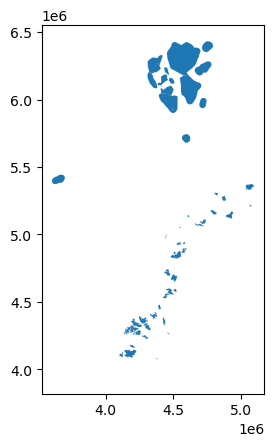

In [43]:
gdf_cdda_filtered_B.plot()

<AxesSubplot: >

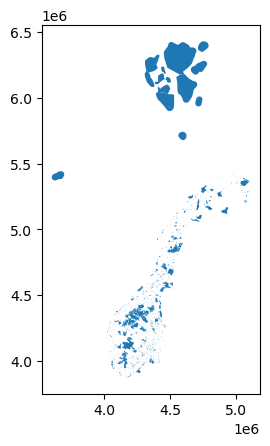

In [28]:
gdf_cdda_NO.plot()

<AxesSubplot: >

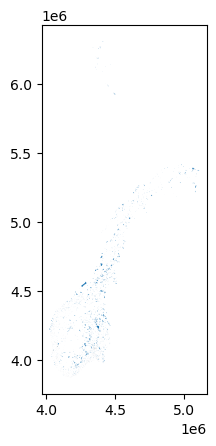

In [44]:
gdf_cdda_NO[gdf_cdda_NO['iucnCategory'] == 'Ia'].plot()

In [ ]:
'/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Vern_0000_norge_25833_FILEGDB.gdb'

In [58]:
protected_areas = fiona.listlayers('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Vern_0000_norge_25833_FILEGDB.gdb')

In [59]:
protected_areas

['Teiggrensepunkt', 'Naturvernområde', 'Naturverngrense']

In [60]:
redlist_species = gpd.read_file('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Vern_0000_norge_25833_FILEGDB.gdb', layer=protected_areas[1])

In [61]:
redlist_species

,faktaark,uuid,identifikasjon_lokalId,identifikasjon_navnerom,kommune,forvaltningsmyndighet,forvaltningsmyndighetType,cddaId,førstegangVernet,forvaltningsplan,...,skogvern,tiltaksbehov,truetVurdering,vernedato,verneform,verneformAggregert,verneforskrift,verneplan,skjøtselplanDato,geometry
0,https://faktaark.naturbase.no/?id=VV00003155,{221BE6E9-4A75-4D34-9919-54E018E9773E},VV00003155,https://www.miljodirektoratet.no/naturbase,3203,Statsforvalteren i Oslo og Viken,statsforvalter,555589640,None,ingenPlan,...,ja,ikkeBehov,ikkeTruet,20150320,naturreservat,naturreservat,https://lovdata.no/forskrift/2015-03-20-232,skogvern,None,"MULTIPOLYGON (((239971.680 6637023.220, 240403..."
1,https://faktaark.naturbase.no/?id=VV00000825,{609A1D24-4D0A-419E-ABA2-23DF577CF0B2},VV00000825,https://www.miljodirektoratet.no/naturbase,1112,Statsforvalteren i Rogaland,statsforvalter,155680,None,ingenPlan,...,ja,ikkeVurdert,,19841221,naturreservat,naturreservat,https://lovdata.no/forskrift/1984-12-21-2207,verneplanLøvskog,19860201,"MULTIPOLYGON (((6643.780 6506797.010, 6549.100..."
2,https://faktaark.naturbase.no/?id=VV00002765,{F0DD71A6-0707-4013-A651-3AD777C615B7},VV00002765,https://www.miljodirektoratet.no/naturbase,5025,Verneområdestyret for Skardsfjella-Hyllingsdal...,verneområdestyre,395337,None,godkjent,...,ja,ikkeVurdert,ikkeVurdert,20090109,naturreservat,naturreservat,https://lovdata.no/forskrift/2009-01-09-25,verneplanVåtmark,None,"MULTIPOLYGON (((337925.330 6963553.450, 338073..."
3,https://faktaark.naturbase.no/?id=VV00001473,{6E57E70D-3A8A-4F37-8DAD-E01202331F8A},VV00001473,https://www.miljodirektoratet.no/naturbase,4226,Hægebostad kommune,kommune,155566,None,ingenPlan,...,ja,behov,truet,19781222,naturreservat,naturreservat,https://lovdata.no/forskrift/1978-12-22-43,verneplanLøvskog,None,"MULTIPOLYGON (((45864.870 6509569.200, 45839.9..."
4,https://faktaark.naturbase.no/?id=VV00003508,{B1DC9D54-40CF-4A89-A718-D310AABA0366},VV00003508,https://www.miljodirektoratet.no/naturbase,3105,Statsforvalteren i Oslo og Viken,statsforvalter,555692032,20190621,ikkeVurdert,...,ja,ikkeVurdert,ikkeVurdert,20200623,naturreservat,naturreservat,https://lovdata.no/forskrift/2020-06-23-1312,skogvern,None,"MULTIPOLYGON (((279622.050 6589585.070, 279636..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3421,https://faktaark.naturbase.no/?id=VV00003931,{2FCF2C77-2954-4670-BCDA-2771B23FA772},VV00003931,https://www.miljodirektoratet.no/naturbase,"4649,4602",Statsforvalteren i Vestland,statsforvalter,555772265,None,ingenPlan,...,,ikkeVurdert,ikkeVurdert,20241220,marintVerneområde,marintVerneområde,https://lovdata.no/forskrift/2024-12-20-3357,marinVerneplan,None,"MULTIPOLYGON (((-4938.180 6938425.430, -3789.7..."
3422,https://faktaark.naturbase.no/?id=VV00003933,{8A6D74AA-A898-4945-8759-20ECC721A7BB},VV00003933,https://www.miljodirektoratet.no/naturbase,3414,Statsforvalteren i Innlandet,statsforvalter,555772268,20241220,ikkeVurdert,...,ja,ikkeVurdert,ikkeVurdert,20241220,naturreservat,naturreservat,https://lovdata.no/forskrift/2024-12-20-3352,skogvern,None,"MULTIPOLYGON (((307574.860 6711719.860, 307405..."
3423,https://faktaark.naturbase.no/?id=VV00003934,{54927F4E-86E4-42B1-AD42-16656D34CB32},VV00003934,https://www.miljodirektoratet.no/naturbase,4642,Statsforvalteren i Vestland,statsforvalter,555772236,None,ingenPlan,...,ja,ikkeBehov,ikkeTruet,20241220,naturreservat,naturreservat,https://lovdata.no/forskrift/2024-12-20-3337,skogvern,None,"MULTIPOLYGON (((108764.800 6790640.850, 108764..."
3424,https://faktaark.naturbase.no/?id=VV00003936,{1DD49D1A-5504-4914-B57D-EE3EFF397AB4},VV00003936,https://www.miljodirektoratet.no/naturbase,4204,Statsforvalteren i Agder,statsforvalter,555772271,20241220,ingenPlan,...,ja,ikkeBehov,ikkeTruet,20241220,naturreservat,naturreservat,https://lovdata.no/forskrift/2024-12-20-3340,skogvern,None,"MULTIPOLYGON (((67196.620 6464520.590, 67195.3..."


In [ ]:
'/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Natur_0000_Norge_25833_Rodlistearter_FGDB.gdb'

In [52]:
redlist_species = gpd.read_file('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Natur_0000_Norge_25833_Rodlistearter_FGDB.gdb')

KeyboardInterrupt: 

In [53]:
RL = fiona.listlayers('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Natur_0000_Norge_25833_Rodlistearter_FGDB.gdb')

In [54]:
RL

['rodlisteartobservasjon',
 'rodlisteartsforekomst_linje',
 'rodlisteartsforekomst_posisjon',
 'rodlisteartsforekomst_omrade',
 'artsforekomstgrense_grense']

In [ ]:
redlist_species

In [56]:
redlist_species = gpd.read_file('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Natur_0000_Norge_25833_Rodlistearter_FGDB.gdb', layer=RL[3])

/fp/homes01/u01/ec-javedm/miniconda3/envs/MediaCloud/lib/python3.10/site-packages/geopandas/io/file.py:399: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  as_dt = pd.to_datetime(df[k], errors="ignore")
/fp/homes01/u01/ec-javedm/miniconda3/envs/MediaCloud/lib/python3.10/site-packages/geopandas/io/file.py:399: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  as_dt = pd.to_datetime(df[k], errors="ignore")


In [57]:
redlist_species

,objid,objtype,kommune,fylke,lokalitet,datauttaksdato,oppdateringsdato,opphav,SHAPE_Length,SHAPE_Area,geometry
0,2341143,RødlisteArtsforekomst,4205,42,"Udvåre sjøfuglreservat, Lindesnes, Ag",2025-03-05 01:19:03+00:00,NaT,Artsdatabanken,3637.117419,832537.230,"MULTIPOLYGON (((39475.700 6453453.020, 39838.7..."
1,9153707,RødlisteArtsforekomst,4205,42,Udvåre,2025-03-13 13:24:57+00:00,NaT,Artsdatabanken,2735.367002,401006.244,"MULTIPOLYGON (((39526.800 6453353.020, 39572.8..."
2,1006312,RødlisteArtsforekomst,4205,42,"Guleholmane sjøfuglreservat, Lindesnes, Ag",2025-03-04 13:00:42+00:00,NaT,Artsdatabanken,1129.455482,91179.500,"MULTIPOLYGON (((33120.670 6455285.030, 33220.6..."
3,9153482,RødlisteArtsforekomst,4205,42,Guleholmane,2025-03-13 13:24:57+00:00,NaT,Artsdatabanken,960.922826,59582.215,"MULTIPOLYGON (((33255.570 6455291.930, 33287.5..."
4,8317610,RødlisteArtsforekomst,4205,42,"Hillegarden, Lindesnes, Ag",2025-03-12 00:45:03+00:00,NaT,Artsdatabanken,2021.979318,281932.500,"MULTIPOLYGON (((33107.670 6455041.030, 33279.6..."
...,...,...,...,...,...,...,...,...,...,...,...
17078,9122738,RødlisteArtsforekomst,0301,03,Alna ved Etterstad,2025-03-13 13:06:50+00:00,NaT,Artsdatabanken,1269.320321,59226.560,"MULTIPOLYGON (((265329.000 6648398.300, 265332..."
17079,3984256,RødlisteArtsforekomst,0301,03,"alnaelva fagerli, Etterstad, Oslo, Os",2025-03-06 06:23:24+00:00,NaT,Artsdatabanken,1253.380216,55069.500,"MULTIPOLYGON (((265354.000 6648384.000, 265334..."
17080,3214278,RødlisteArtsforekomst,0301,03,"Økernveien, Oslo, Os",2025-03-05 14:46:14+00:00,NaT,Artsdatabanken,623.046402,1848.000,"MULTIPOLYGON (((265805.000 6651366.000, 265809..."
17081,7141089,RødlisteArtsforekomst,0301,03,Lindbckdammen,2025-03-09 23:03:29+00:00,NaT,Artsdatabanken,144.762343,1466.525,"MULTIPOLYGON (((264997.200 6643994.500, 264992..."


In [ ]:
reindeer_areas_layer = gpd.read_file(reindeer_areas_all)

In [35]:
src_infra.meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': -3.4028230607370965e+38,
 'width': 12638,
 'height': 16329,
 'count': 1,
 'crs': CRS.from_epsg(32633),
 'transform': Affine(100.0, 0.0, -97999.99999123206,
        0.0, -100.0, 8048200.000123367)}

<AxesSubplot: >

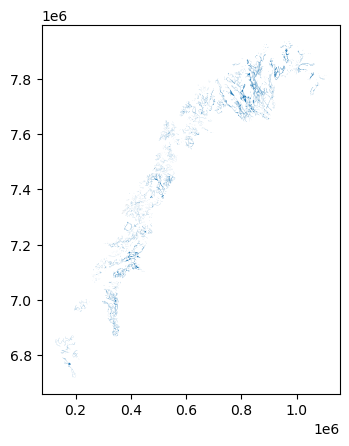

In [98]:
reindeer_areas_layer.plot()

In [90]:
reindeer_areas = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/0000_25833_reindrift-vinterbeite_gdb.gdb'
layers_reindeer_areas = fiona.listlayers(reindeer_areas)
print (layers_reindeer_areas)

['rein_arstidsbeite_vinter_flate']


In [91]:
reindeer_areas_layer = gpd.read_file(reindeer_areas)

In [94]:
reindeer_areas_layer['sesomr'].unique()

array([ 9., 10., nan])

In [46]:
recreational_areas_N = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/KartlagteFriluftslivsomr_0000_norge_25833_FILEGDB.gdb'
layers_recreational_areas = fiona.listlayers(recreational_areas_N)
print (layers_recreational_areas)

['KartlagteFriluftslivsomr_0000_norge']


In [62]:
filtered_data = recreational_areas_layer[recreational_areas_layer['brukerfrekvens'] >= '2']

In [51]:
recreational_areas_layer['brukerfrekvens'].unique()

array(['3', '2', '4', '1', '5', None], dtype=object)

In [52]:
recreational_areas_layer['brukerfrekvens_beskrivelse'].unique()

array(['Middels', 'Noe', 'Ganske stor', 'Liten', 'Stor', '',
       'Ikke registrert'], dtype=object)

In [335]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRVOLMB.tif') as src_VOLMB:
    # Read the data
        data_VOLMB1 = src_VOLMB.read(1)  # Reads the first band of the image
        data_VOLMB2 = src_VOLMB.read(2)
        data_VOLMB3 = src_VOLMB.read(3)

In [10]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Infrastrukturindeks_UTM32/NY_INFRA_IND.tif') as src_infra:
    # Read the data
    data_infra = src_infra.read(1)
    

In [29]:
data_infra.size

206365902

In [34]:
np.sum(data_infra == 0)/(data_infra.size-np.sum(data_infra == -3.4028230607370965e+38))

0.9191812433976542

In [25]:
 np.sum(data_infra == -3.4028230607370965e+38)

45294

In [ ]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Infrastrukturindeks_UTM32/NY_INFRA_IND.tif') as src_infra:
    # Read the data
        data_infra = src_infra.read(1)  # Reads the first band of the image

flattened_data = data_infra.flatten()
cleaned_data = flattened_data[(~np.isnan(flattened_data)) & (flattened_data != -3.4028230607370965e+38)]
num_classes = 3  # Define the number of desired classes
jenks_breaks_infra = mapclassify.JenksCaspall(cleaned_data, k=num_classes)

/fp/homes01/u01/ec-javedm/miniconda3/envs/MediaCloud/lib/python3.10/site-packages/mapclassify/classifiers.py:255: UserWarning: Not enough unique values in array to form 3 classes. Setting k to 2.
  warnings.warn(
/fp/homes01/u01/ec-javedm/miniconda3/envs/MediaCloud/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/fp/homes01/u01/ec-javedm/miniconda3/envs/MediaCloud/lib/python3.10/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in true_divide
  ret = ret.dtype.type(ret / rcount)


In [31]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Infrastrukturindeks_UTM32/NY_INFRA_IND.tif') as src_infra:
    # Read the data
        data_infra = src_infra.read(1)  # Reads the first band of the image

flattened_data = data_infra.flatten()
cleaned_data = flattened_data[(~np.isnan(flattened_data)) & (flattened_data != -3.4028230607370965e+38) & (flattened_data != 0)]
num_classes = 3  # Define the number of desired classes
jenks_breaks_infra = mapclassify.JenksCaspall(cleaned_data, k=num_classes)

In [32]:
jenks_breaks_infra

JenksCaspall

   Interval        Count
------------------------
[ 0.16,  3.47] | 8695616
( 3.47,  7.50] | 4288084
( 7.50, 15.43] | 3690875

In [12]:
src_infra.meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': -3.4028230607370965e+38,
 'width': 12638,
 'height': 16329,
 'count': 1,
 'crs': CRS.from_epsg(32633),
 'transform': Affine(100.0, 0.0, -97999.99999123206,
        0.0, -100.0, 8048200.000123367)}

25th Percentile cutoff value: 1.738351821899414
50th Percentile cutoff value: 3.257388114929199
75th Percentile cutoff value: 6.943431854248047


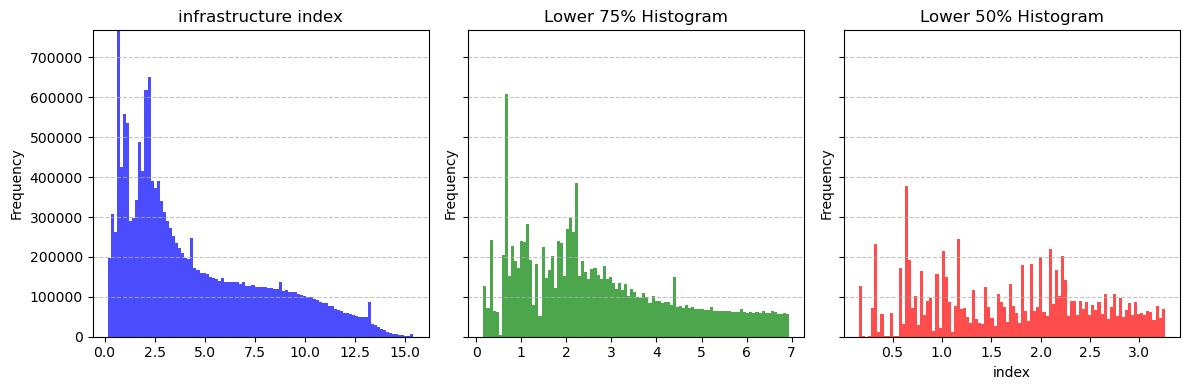

In [22]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Forest_work/Infrastrukturindeks_UTM32/NY_INFRA_IND.tif') as src_infra:
    # Read the data
        data_infra = src_infra.read(1)  # Reads the first band of the image

plot_histogram(data_infra, bins=100, title='infrastructure index',
               xlabel='index', ylabel='Frequency')

## Histogram plot

In [21]:
def plot_histogram(data, bins=50, title='histogram', xlabel='Value', ylabel='Frequency',):
    """
    Plots a histogram for the given data array.
    
    Parameters:
    data (array-like): The input data to plot.
    bins (int): Number of bins for the histogram.
    title (str): Title of the histogram plot.
    xlabel (str): Label for the x-axis.
    ylabel (str): Label for the y-axis.
    """
    # Flatten the data if it's multi-dimensional (e.g., raster data)
    flattened_data = data.flatten()
    # Remove nodata values (assuming -9999 represents nodata)
    #cleaned_data = flattened_data[(flattened_data != -9999) & (~np.isnan(flattened_data))] #for forest data
    #cleaned_data = flattened_data[(flattened_data != -3.3999999521443642e+38) & (~np.isnan(flattened_data))] #for birds data
    cleaned_data = flattened_data[(flattened_data != -3.4028230607370965e+38) & (~np.isnan(flattened_data)) & (flattened_data != 0)]
    # Calculate quantiles
    percentile_25 = np.percentile(cleaned_data, 25)
    percentile_50 = np.percentile(cleaned_data, 50)
    percentile_75 = np.percentile(cleaned_data, 75)
    
    # Print percentile cutoff values
    print(f"25th Percentile cutoff value: {percentile_25}")
    print(f"50th Percentile cutoff value: {percentile_50}")
    print(f"75th Percentile cutoff value: {percentile_75}")    # Calculate the quartiles

    # Data for percentile values
    lower_75_data = cleaned_data[cleaned_data <= percentile_75]
    lower_50_data = cleaned_data[cleaned_data <= percentile_50]
    


    # Calculate histograms and determine the max frequency
    full_hist, _ = np.histogram(cleaned_data, bins=bins)
    lower_75_hist, _ = np.histogram(lower_75_data, bins=bins)
    lower_50_hist, _ = np.histogram(lower_50_data, bins=bins)
    
    max_frequency = max(full_hist.max(), lower_75_hist.max(), lower_50_hist.max())
    
    # Plot the histogram
    fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
    
    axs[0].hist(cleaned_data, bins=bins, color='blue', alpha=0.7)
    axs[0].set_title(title)
    axs[0].set_xlabel('')
    axs[0].set_ylabel(ylabel)
    axs[0].set_ylim([0, max_frequency])
    axs[0].grid(axis='y', linestyle='--', alpha=0.75)

    # Lower percentile histogram
    axs[1].hist(lower_75_data, bins=bins, color='green', alpha=0.7)
    axs[1].set_title('Lower 75% Histogram')
    axs[1].set_xlabel('')
    axs[1].set_ylabel(ylabel)
    axs[1].set_ylim([0, max_frequency])
    axs[1].grid(axis='y', linestyle='--', alpha=0.75)

    # Upper percentile histogram
    axs[2].hist(lower_50_data, bins=bins, color='red', alpha=0.7)
    axs[2].set_title('Lower 50% Histogram')
    axs[2].set_xlabel(xlabel)
    axs[2].set_ylabel(ylabel)
    axs[2].set_ylim([0, max_frequency])
    axs[2].grid(axis='y', linestyle='--', alpha=0.75)
    

    plt.tight_layout()
    plt.show()

25th Percentile cutoff value: 6.0
50th Percentile cutoff value: 8.0
75th Percentile cutoff value: 11.0


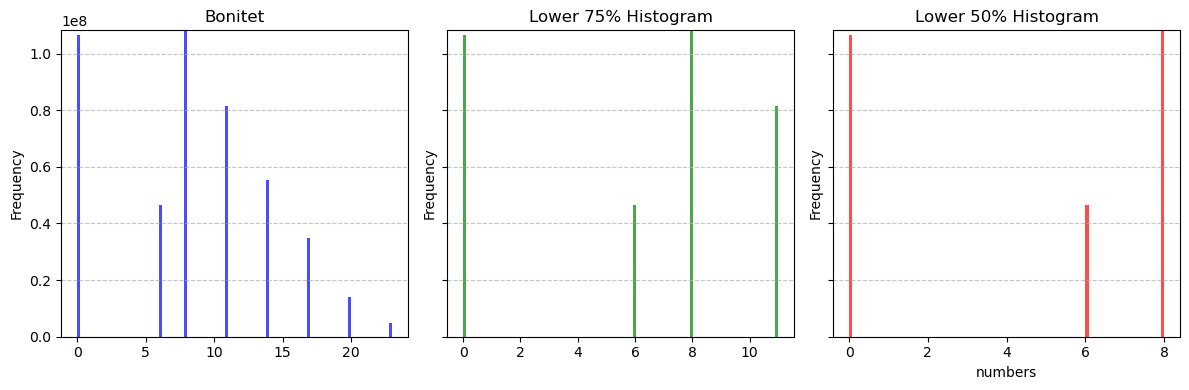

In [74]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRBONITET.tif') as src_BON:
    # Read the data
        data_BON = src_BON.read(1)  # Reads the first band of the image


plot_histogram(data_BON, bins=100, title='Bonitet',
               xlabel='numbers', ylabel='Frequency')

25th Percentile cutoff value: 19.0
50th Percentile cutoff value: 48.0
75th Percentile cutoff value: 99.0


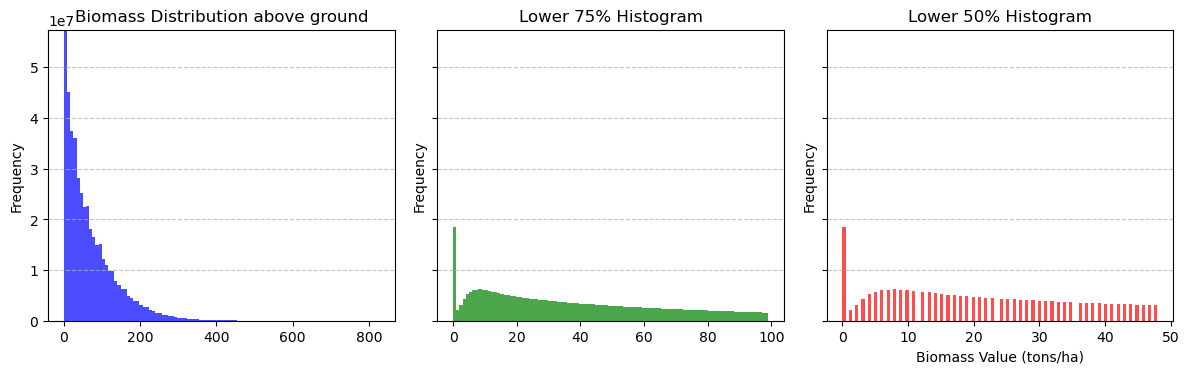

In [15]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRBMO.tif') as src_BMO:
    # Read the data
        data_BMO1 = src_BMO.read(1)  # Reads the first band of the image
        data_BMO2 = src_BMO.read(2)
        data_BMO3 = src_BMO.read(3)

plot_histogram(data_BMO1, bins=100, title='Biomass Distribution above ground',
               xlabel='Biomass Value (tons/ha)', ylabel='Frequency')

25th Percentile cutoff value: 476.0
50th Percentile cutoff value: 783.0
75th Percentile cutoff value: 1225.0


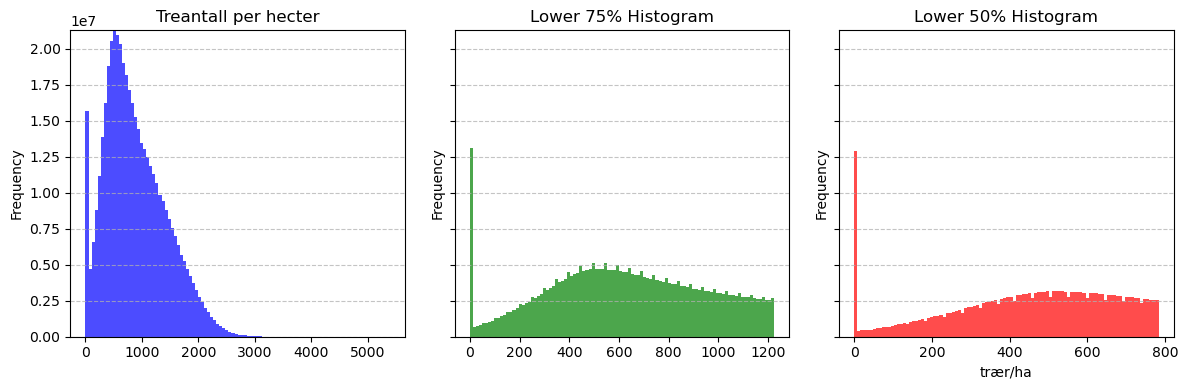

In [16]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREANTALL.tif') as src_TREA:
    # Read the data
        data_TREA1 = src_TREA.read(1)  # Reads the first band of the image
        data_TREA2 = src_TREA.read(2)
        data_TREA3 = src_TREA.read(3)
plot_histogram(data_TREA1, bins=100, title='Treantall per hecter',
               xlabel='trær/ha', ylabel='Frequency')

In [17]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREALDER.tif') as src_TREALD:
    # Read the data
        data_TREALD1 = src_TREALD.read(1)  # Reads the first band of the image
        data_TREALD2 = src_TREALD.read(2)
        data_TREALD3 = src_TREALD.read(3)

25th Percentile cutoff value: 59.0
50th Percentile cutoff value: 83.0
75th Percentile cutoff value: 109.0


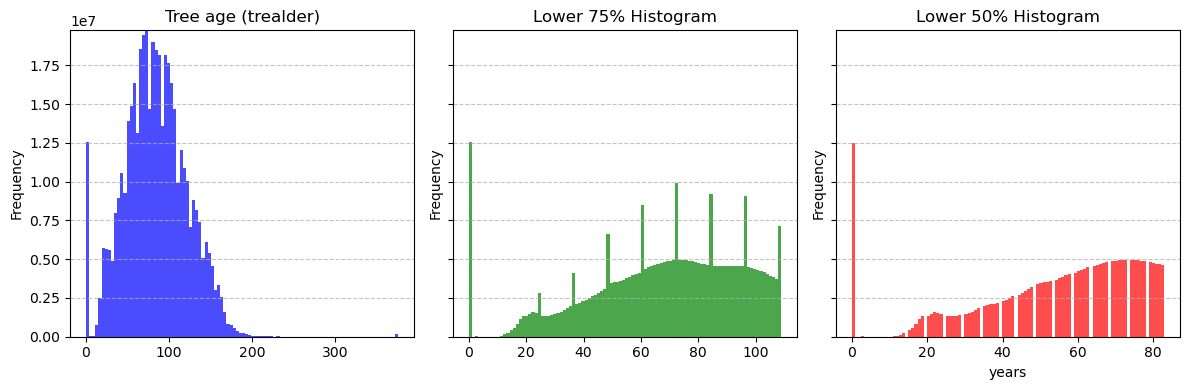

In [18]:
plot_histogram(data_TREALD1, bins=100, title='Tree age (trealder)',
               xlabel='years', ylabel='Frequency')

In [19]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRGRFLATE.tif') as src_GRF:
    # Read the data
        data_GRF1 = src_GRF.read(1)  # Reads the first band of the image
        data_GRF2 = src_GRF.read(2)
        data_GRF3 = src_GRF.read(3)

25th Percentile cutoff value: 6.0
50th Percentile cutoff value: 13.0
75th Percentile cutoff value: 23.0


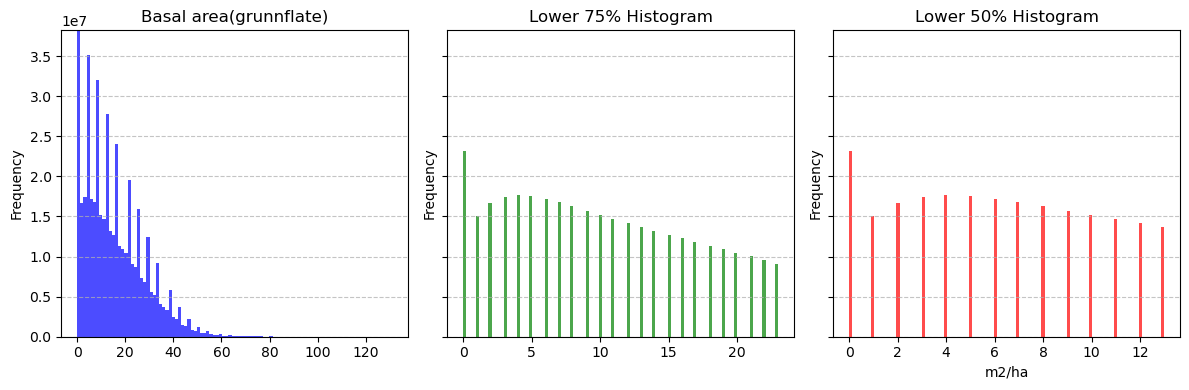

In [20]:
plot_histogram(data_GRF1, bins=100, title='Basal area(grunnflate)',
               xlabel='m2/ha', ylabel='Frequency')

In [21]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRVOLMB.tif') as src_VOLMB:
    # Read the data
        data_VOLMB1 = src_VOLMB.read(1)  # Reads the first band of the image
        data_VOLMB2 = src_VOLMB.read(2)
        data_VOLMB3 = src_VOLMB.read(3)

25th Percentile cutoff value: 24.0
50th Percentile cutoff value: 67.0
75th Percentile cutoff value: 149.0


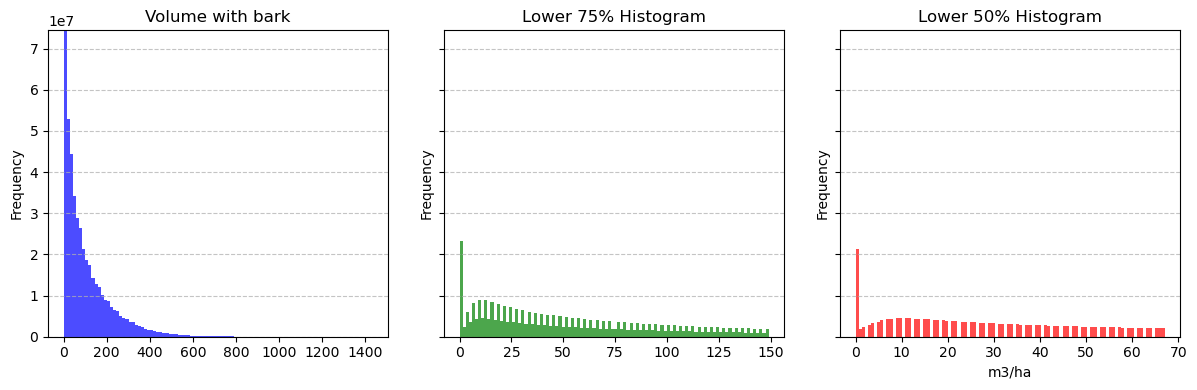

In [22]:
plot_histogram(data_VOLMB1, bins=100, title='Volume with bark',
               xlabel='m3/ha', ylabel='Frequency')

In [23]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRKRONEDEK.tif') as src_KRO:
    # Read the data
        data_KRO1 = src_KRO.read(1)  # Reads the first band of the image

25th Percentile cutoff value: 25.0
50th Percentile cutoff value: 62.0
75th Percentile cutoff value: 89.0


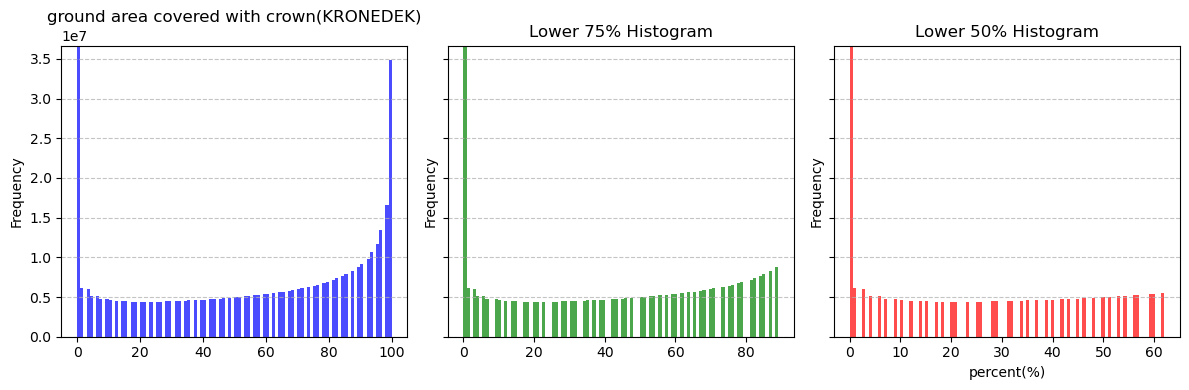

In [24]:
plot_histogram(data_KRO1, bins=100, title='ground area covered with crown(KRONEDEK)',
               xlabel='percent(%)', ylabel='Frequency')

25th Percentile cutoff value: 32.447975158691406
50th Percentile cutoff value: 63.159549713134766
75th Percentile cutoff value: 97.72682189941406


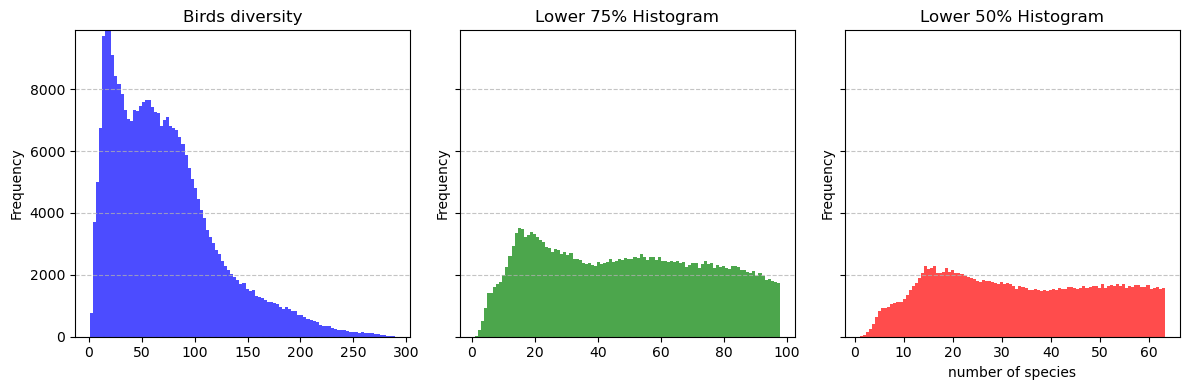

In [69]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Data_Maps_NTNU/HS_Bird diversity.tif') as src_bird:
    # Read the data
        data_bird = src_bird.read(1)
plot_histogram(data_bird, bins=100, title='Birds diversity',
               xlabel='number of species', ylabel='Frequency')

25th Percentile cutoff value: 32.447975158691406
50th Percentile cutoff value: 63.159549713134766
75th Percentile cutoff value: 97.72682189941406


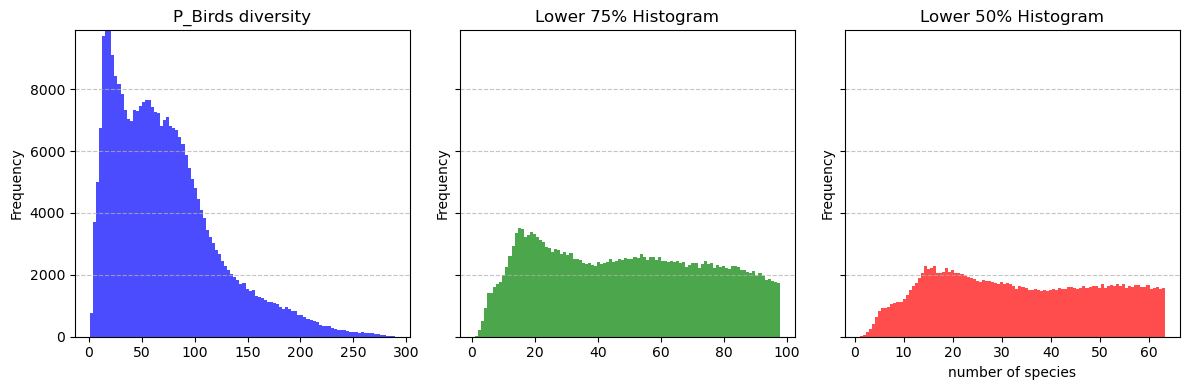

In [70]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Data_Maps_NTNU/P_Bird diversity.tif') as src_birdP:
    # Read the data
        data_birdP = src_birdP.read(1)
plot_histogram(data_bird, bins=100, title='P_Birds diversity',
               xlabel='number of species', ylabel='Frequency')

# Density curve Plots

In [215]:
jenks_breaks_birdsHS

JenksCaspall

    Interval        Count
-------------------------
[  1.06,  53.05] | 130668
( 53.05, 112.91] | 127277
(112.91, 289.24] |  56240

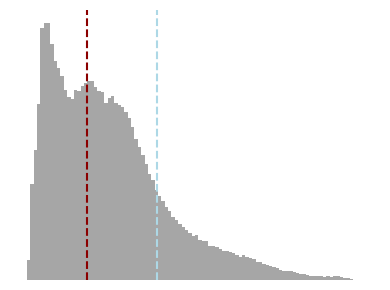

In [219]:
# Open the raster image file
#with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRKRONEDEK.tif') as src_data:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/Data_Maps_NTNU/HS_Bird diversity.tif') as src_data:
    # Read the data from the first band
    data_plot = src_data.read(1)

# Flatten the data if it's multi-dimensional and remove nodata values
flattened_data = data_plot.flatten()
#nodata_value = -9999  # Set according to your data context
nodata_value = -3.3999999521443642e+38
cleaned_data = flattened_data[(flattened_data != nodata_value) & (~np.isnan(flattened_data))]

# Calculate specific threshold points (example percentiles)
threshold_25 = 53 #np.percentile(cleaned_data, 25)
threshold_50 = 113 #np.percentile(cleaned_data, 50)
#threshold_75 = 151 #np.percentile(cleaned_data, 75)

# Plot the histogram
fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(cleaned_data, bins=100, color='grey', alpha=0.7)

# Add vertical lines at specified thresholds
ax.axvline(threshold_25, color='darkred', linestyle='--', linewidth=1.5)
ax.axvline(threshold_50, color='lightblue', linestyle='--', linewidth=1.5)
#ax.axvline(threshold_75, color='orange', linestyle='--', linewidth=1.5)

# Customizations for publication-ready appearance


# Remove axis lines for a clean appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()

#plt.savefig('/fp/homes01/u01/ec-javedm/ec85/models/shahzad/plots_forests/hist_Jenks/birdsHS_hist.png', dpi=300, bbox_inches='tight')
#plt.savefig('/fp/homes01/u01/ec-javedm/ec85/models/shahzad/plots_forests/hist_Jenks/birdsHS_hist_T.png', dpi=300, transparent=True, bbox_inches='tight')


plt.show()


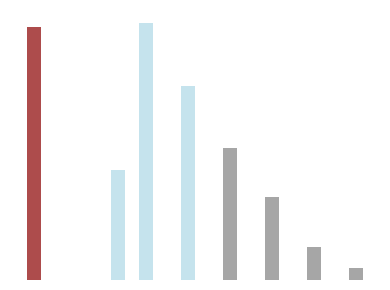

In [221]:
# plot for the discrete values of Bonitet
#with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRBONITET.tif') as src_data:
    # Read the data from the first band
#    data_plot = src_data.read(1)

# Flatten the data if it's multi-dimensional and remove nodata values
#flattened_data = data_plot.flatten()
#nodata_value = -9999  # Set according to your data context
#cleaned_data = flattened_data[(flattened_data != nodata_value) & (~np.isnan(flattened_data))]

# [0,     6,     8,    11,    14,    17,    20,    23]

#highlight_values = [0, 6, 8, 11]

# Plot the histogram
fig, ax = plt.subplots(figsize=(4, 3))

n, bins, patches = ax.hist(cleaned_data, bins=np.arange(min(cleaned_data)-0.5, max(cleaned_data)+1.5), color='grey', alpha=0.7)

bin_centers = 0.5 * (bins[:-1] + bins[1:])

for patch, center in zip(patches, bin_centers):
    if center == 0:
        patch.set_facecolor('darkred')  # Special color for 0
    elif center in highlight_values[1:]:
        patch.set_facecolor('lightblue')  # Highlighting [6, 8, 11]


# Customizations for publication-ready appearance


# Remove axis lines for a clean appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()

#plt.savefig('/fp/homes01/u01/ec-javedm/ec85/models/shahzad/plots_forests/hist_Jenks/Bonitet_hist.png', dpi=300, bbox_inches='tight')
#plt.savefig('/fp/homes01/u01/ec-javedm/ec85/models/shahzad/plots_forests/hist_Jenks/Bonitet_hist_T.png', dpi=300, transparent=True, bbox_inches='tight')


plt.show()


In [ ]:
sharedinputpath = "../../../models/max/special_issue/shared_input/"

In [ ]:
europe = gpd.read_file("resources/data/NO-NUTS3.geojson").replace({"UK":"GB","EL":"GR"}).rename(columns={"NUTS_ID":"index"}).loc[:,["index","geometry"]].sort_values("index").set_index('index')#.loc[desired_regions]

In [ ]:
fig, ax = plt.subplots()

gpd.clip(europe,(0,55,35,74)).plot(
    ax=ax,
    facecolor="none", 
    edgecolor="black",
    alpha = 0.3
)

In [ ]:
categories = ['Fauna','Natur','Neigh','Sami']
scenarios = ['Low','High']

In [ ]:
gpd.read_file('mo/resources/scenario_exclusions/

In [ ]:
#categories = ['Sami','Natur']
#scenarios = ['Low','Med']
row_nr = 0
column_nr = 0
a = 'N/A'

#norway_area = europe.to_crs('EPSG:3857').area.sum()

fig = plt.figure(figsize=(4*3.54,6*3.54), dpi=300,layout="constrained")

gs = fig.add_gridspec(4,2)

for category in categories:
    for scenario in scenarios:
        ax1 = fig.add_subplot(gs[row_nr,column_nr])
        df = gpd.read_file("mo/resources/scenario_exclusions/" + str(category) + "_" + str(scenario) + "_Exc.zip").to_crs('EPSG:4326')
        df.plot(
            ax=ax1,
        )
        
        #a = df.area.sum()/norway_area
        
        gpd.clip(europe,(0,55,35,74)).plot(
            ax=ax1,
            facecolor="none", 
            edgecolor="black",
            alpha = 0.3
        )
        
        ax1.set_title(str(category) + str(scenario) + ' Area: ' + str(a))
        ax1.set_xlim(0,35)
        ax1.set_ylim(55,74)
        
        column_nr += 1
        if column_nr == 2:
            column_nr = 0
            row_nr += 1
   

In [ ]:
pv_low = gpd.read_file("mo/resources/scenario_exclusions/PV_Low_Exc.zip").to_crs('EPSG:4326')

In [ ]:
#axs=plt.subplots(1,3)
fig = plt.figure(figsize=(4*3.54,6*3.54), dpi=300,layout="constrained")

gs = fig.add_gridspec(1,3)

ax1 = fig.add_subplot(gs[0,0])
pv_low.plot(
    ax=ax1
)

#ax2 = fig.add_subplot(gs[0,1])
#pv_med.plot(
#    ax=ax2
#)
#
#ax3 = fig.add_subplot(gs[0,2])
#pv_high.plot(
#    ax=ax3
#)

ax1.set_xlim(0,35)
ax1.set_ylim(55,74)

In [ ]:
pv_med = gpd.read_file("mo/resources/scenario_exclusions/PV_Medium_Exc.zip").to_crs('EPSG:4326')

In [ ]:
pv_high = gpd.read_file("resources/data/PV_High_Exc.zip").to_crs('EPSG:4326')

In [ ]:
technical = gpd.read_file("mo/resources/scenario_exclusions/Techn_All_Exc.zip").to_crs('EPSG:4326')
fauna_low = gpd.read_file("mo/resources/scenario_exclusions/Fauna_Low_Exc.zip").to_crs('EPSG:4326')
#neigh_high = gpd.read_file("mo/resources/scenario_exclusions/Neigh_High_Exc.zip").to_crs('EPSG:4326')
#neigh_med = gpd.read_file("mo/resources/scenario_exclusions/Neigh_Med_Exc.zip").to_crs('EPSG:4326')
natur_high = gpd.read_file("mo/resources/scenario_exclusions/Natur_High_Exc.zip").to_crs('EPSG:4326')

In [ ]:
technical.plot(figsize=(10,6))

## Areas

In [ ]:
neigh_med.to_crs('EPSG:3857').plot()

In [ ]:
neigh_med.to_crs('EPSG:3857').area.sum()

In [ ]:
neigh_med.to_crs('EPSG:3857').area.sum()/europe.to_crs('EPSG:3857').area.sum()

In [ ]:
europe.to_crs('EPSG:3857').area.sum()

In [ ]:
technical.to_crs('EPSG:3857').area.sum()

## Overlay

In [ ]:
df_sami_low = gpd.read_file('resources/data/Sami_Low_Exc.zip').to_crs('EPSG:4326')
df_sami_med = gpd.read_file('resources/data/Sami_Med_Exc.zip').to_crs('EPSG:4326')
df_sami_hig = gpd.read_file('resources/data/Sami_High_Exc.zip').to_crs('EPSG:4326')
extra_area = gpd.read_file('resources/data/0000_25833_reindrift-konsesjonsomrade_shp.zip').to_crs('EPSG:4326')
extra_area_buff = extra_area.copy()
extra_area_buff['geometry'] = extra_area_buff['geometry'].buffer(0.05)

In [ ]:
extra_area.plot()
extra_area_buff.plot()

In [ ]:
df_sami_low['savedindex'] = df_sami_low.index
df_sami_med['savedindex'] = df_sami_med.index
df_sami_hig['savedindex'] = df_sami_hig.index

intersecting_low = extra_area.sjoin(df_sami_low, how='inner')['savedindex']
intersecting_med = extra_area.sjoin(df_sami_med, how='inner')['savedindex']
intersecting_hig = extra_area_buff.sjoin(df_sami_hig, how='inner')['savedindex']

df_sami_low_new = df_sami_low[~df_sami_low.savedindex.isin(intersecting_low)]
df_sami_med_new = df_sami_med[~df_sami_med.savedindex.isin(intersecting_med)]
df_sami_hig_new = df_sami_hig[~df_sami_hig.savedindex.isin(intersecting_hig)]

In [ ]:
row_nr = 0
column_nr = 0

fig = plt.figure(figsize=(4*3.54,6*3.54), dpi=300,layout="constrained")

gs = fig.add_gridspec(3,2)

ax1 = fig.add_subplot(gs[0,0])
df_sami_low.plot(ax=ax1,label='df_sami_low')
ax1.set_title('df_sami_low')
ax1.set_xlim(6,33)
ax1.set_ylim(61,72)

ax1 = fig.add_subplot(gs[0,1])
df_sami_low_new.plot(ax=ax1)
ax1.set_title('df_sami_low_new')
ax1.set_xlim(6,33)
ax1.set_ylim(61,72)

ax1 = fig.add_subplot(gs[1,0])
df_sami_med.plot(ax=ax1)
ax1.set_title('df_sami_med')
ax1.set_xlim(6,33)
ax1.set_ylim(61,72)

ax1 = fig.add_subplot(gs[1,1])
df_sami_med_new.plot(ax=ax1)
ax1.set_title('df_sami_med_new')
ax1.set_xlim(6,33)
ax1.set_ylim(61,72)

ax1 = fig.add_subplot(gs[2,0])
df_sami_hig.plot(ax=ax1)
ax1.set_title('df_sami_hig')
ax1.set_xlim(6,33)
ax1.set_ylim(61,72)

ax1 = fig.add_subplot(gs[2,1])
df_sami_hig_new.plot(ax=ax1)
ax1.set_title('df_sami_hig_new')
ax1.set_xlim(6,33)
ax1.set_ylim(61,72)

plt.savefig('sami_overlays.pdf',bbox_inches='tight')

In [ ]:
sami_list = [df_sami_low_new]

In [ ]:
for item in sami_list:
    item.plot()

In [ ]:
df_sami_low_new.to_file('sami_low_new.geojson',driver='GeoJSON')
df_sami_med_new.to_file('sami_med_new.geojson',driver='GeoJSON')
df_sami_hig_new.to_file('sami_hig_new.geojson',driver='GeoJSON')

In [ ]:
gpd.read_file('sami_hig_new.geojson').plot()